# 04 Experiment with Neural Networks

In [ ]:
# Standard library
import gc
import os
import pickle
import time
from datetime import datetime
from itertools import chain
from pathlib import Path
from typing import Any, Protocol

# Third-party libraries
import matplotlib.pyplot as plt
import mlflow
import mlflow.tensorflow
import numpy as np
import optuna
import pandas as pd
import polars as pl
import seaborn as sns
import tensorflow as tf

import keras
from keras import Model, layers
from mlflow.entities import Run
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
)
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import class_weight
from tensorflow.keras.models import load_model

# Local application imports
from ixbrl_ai.data import get_split
from ixbrl_ai.display import display_wide, heading
from ixbrl_ai.sample import DataSample

from ixbrl_ai.test import (
    coerce_to_label_array,
    test_model_over_populations,
    log_population_test_results_to_mlflow,
    load_population_test_results_from_mlflow,
    IXBRL_TEXT_CLASSIFICATION_TEST_CASES
)

%load_ext autoreload
%autoreload 2

/Users/unparagoned/Code/AI_L7/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# 1. Config, setup mlflow, load data

In [3]:
SEED = 42
keras.utils.set_random_seed(SEED)
np.random.seed(SEED)

experiment_name = "ixbrl-nn"
mlflow.set_experiment(experiment_name)
mlflow.tensorflow.autolog()


2026/05/31 20:11:04 WARNING mlflow.utils.autologging_utils: MLflow tensorflow autologging is known to be compatible with 2.16.0 <= tensorflow, but the installed version is 2.15.1. If you encounter errors during autologging, try upgrading / downgrading tensorflow to a compatible version, or try upgrading MLflow.


In [54]:
X = "canonical_description"
y = "label"
dataset_version = "v13"
dataset_name = f"data/canonicalized_split_{dataset_version}.parquet"
dataset_pl = pl.read_parquet(dataset_name)
subset = DataSample.sample_1_pct
test_col = "test_5_pct"

dataset_test_pl = pl.read_parquet("data/canonicalized_split_v16.parquet")

combined_results_pl = pl.DataFrame()

## 1.1 Label encode

In [11]:
le = LabelEncoder()
le.classes_ = dataset_pl.select("label", "canonical_label").unique().sort("label")["canonical_label"].to_numpy()

## 1.2 Train and test datasets

In [ ]:
train_pl = dataset_pl.filter(pl.col(subset.label))
test_pl = dataset_pl.filter(pl.col(test_col))



## 1.3 Class weights

In [13]:
classes = np.unique(dataset_pl[y].to_list())
weights = class_weight.compute_class_weight("balanced", classes=classes, y=dataset_pl[y].to_list())
class_weights = {int(c): w for c, w in zip(classes, weights)}

In [14]:
max_tokens = len(set(dataset_pl[X].str.split(" ").explode()))
max_train_1_tokens = len(set(train_pl[X].str.split(" ").explode()))
max_train_tokens = len(set(dataset_pl.filter(pl.col("train"))[X].str.split(" ").explode()))
output_dim = max_tokens
output_sequence_length = max([len(words) for words in dataset_pl[X].str.split(" ")])
num_classes = len(dataset_pl[y].unique())

print(f'Max tokens: {max_tokens}')
print(f'Max train tokens: {max_train_tokens}')
print(f'Max train 1 tokens: {max_train_1_tokens}')
print(f'Output dimension: {output_dim}')
print(f'Output sequence length: {output_sequence_length}')
print(f'Number of classes: {num_classes}')

Max tokens: 3871
Max train tokens: 2710
Max train 1 tokens: 396
Output dimension: 3871
Output sequence length: 15
Number of classes: 826


Number of tokens in the 1% population is quite a bit lower than the full training set. 

# 2. Optuna functions and helpers

## 2.1 Tokenize and vectorise

In [15]:
# Tokenize and vectorise
# This is fairly simple. BERT would capture semantic meaning. But the Embedding layer should pick up enough meaning that we need.
# Also BERT is much bigger, so this would be faster. Could consider if we have poor results.
vectorize = layers.TextVectorization(
    max_tokens=max_tokens,
    standardize='lower_and_strip_punctuation',
    split='whitespace',
    output_mode='int',
    output_sequence_length=output_sequence_length
)

# Enable for first run to build vocab
# vectorize.adapt(dataset_pl[X].to_list())
# vocab = vectorize.get_vocabulary()
# with open('data/nn/vocab.pkl', 'wb') as f:
#     pickle.dump(vocab, f)


with open('data/nn/vocab.pkl', 'rb') as f:
    vocab = pickle.load(f)

vectorize.set_vocabulary(vocab)

2026-05-31 20:15:10.739494: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Max
2026-05-31 20:15:10.739518: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 128.00 GB
2026-05-31 20:15:10.739524: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 53.76 GB
2026-05-31 20:15:10.739558: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-05-31 20:15:10.739569: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [16]:
vectorize_1_2_ngrams = layers.TextVectorization(
    max_tokens=max_tokens,
    standardize='lower_and_strip_punctuation',
    split='whitespace',
    output_mode='int',
    output_sequence_length=output_sequence_length,
    ngrams=(1,2)
)
# vectorizer_1_2_ngrams.adapt(dataset_pl[X].to_list())

# vocab = vectorizer_1_2_ngrams.get_vocabulary()
# with open('data/nn/vocab_1_2_ngrams.pkl', 'wb') as f:
#     pickle.dump(vocab, f)

with open('data/nn/vocab_1_2_ngrams.pkl', 'rb') as f:
    vocab = pickle.load(f)

vectorize_1_2_ngrams.set_vocabulary(vocab)

## 2.2 Functions

In [ ]:
X_train = train_pl[X].to_numpy()
y_train = train_pl[y].to_numpy()
X_val = test_pl[X].to_numpy()
y_val = test_pl[y].to_numpy()

def create_datasets(batch_size: int) -> tuple[tf.data.Dataset, tf.data.Dataset]:
    train_ds = (
        tf.data.Dataset.from_tensor_slices((X_train, y_train))
        .shuffle(buffer_size=len(X_train), seed=SEED)
        .batch(batch_size)
        .prefetch(tf.data.AUTOTUNE)
        # .prefetch(1)
    )

    val_ds = (
        tf.data.Dataset.from_tensor_slices((X_val, y_val))
        .batch(batch_size)
        .prefetch(tf.data.AUTOTUNE)
        # .prefetch(1)
    ) 
    return train_ds, val_ds
class F1MacroCallback(keras.callbacks.Callback):
    def __init__(self, validation_data):
        super().__init__()
        self.validation_data = validation_data
        if isinstance(self.validation_data, tf.data.Dataset):
            val_X, val_y = [], []
            for batch in self.validation_data:
                X_batch, y_batch = batch
                val_X.append(X_batch.numpy())
                val_y.append(y_batch.numpy())
            self.val_X = np.concatenate(val_X, axis=0)
            self.val_y = np.concatenate(val_y, axis=0)
            self.validation_data = (self.val_X, self.val_y)
            del val_X, val_y
        else:
            self.val_X, self.val_y = self.validation_data

        self.epoch_start_time = time.time()
    
    def on_epoch_begin(self, epoch, logs=None):
        self.epoch_start_time = time.time()

    def on_epoch_end(self, epoch, logs=None):
        epoch_duration = time.time() - self.epoch_start_time
        val_predictions_raw = self.model.predict(self.val_X, batch_size=512)
        val_predictions = np.argmax(val_predictions_raw, axis=1)
        del val_predictions_raw

        f1_macro = f1_score(self.val_y, val_predictions, average='macro')
        del val_predictions
        
        print(f' - val_f1_macro: {f1_macro:.4f} - epoch_duration: {epoch_duration:.2f}s')
        if logs is not None:
            logs['val_f1_macro'] = f1_macro
            logs['epoch_duration'] = epoch_duration

    def cleanup(self):
        self.val_X = None
        self.val_y = None
        self.model = None

class FixedTrial:
    def __init__(self, params: dict[str, any]) -> None:
        self.params = params

    def suggest_categorical(self, name: str, choices: list) -> any:
        return self.params[name]
    
    def suggest_int(self, name: str, low: int, high: int, step: int = 1, log: bool = False) -> int:
        return self.params[name]
    
    def suggest_float(self, name: str, low: float, high: float, step: float = None, log: bool = False) -> float:
        return self.params[name]
    
def create_model(trial: optuna.Trial | FixedTrial, vectorize: layers.TextVectorization) -> keras.Model:

    arch = trial.suggest_categorical("arch", ["dense", "lstm", "gru", "cnn", "bi"])
    activation = trial.suggest_categorical("activation", ["relu", "gelu", "elu"])
    learning_rate = trial.suggest_float("learning_rate", 1e-5, 1e-2, log=True)
    dropout_rate = trial.suggest_float("dropout_rate", 0.1, 0.5)
    embedding_dim = trial.suggest_int("embedding_dim", 64, 512)
    dense_units = trial.suggest_int("dense_units", 64, 512)
    n_dense_layers = trial.suggest_int("n_dense_layers", 1, 3)

    inputs = keras.Input(shape=(1,), dtype = tf.string)
    x = vectorize(inputs)
    x = layers.Embedding(input_dim = max_tokens,
                        output_dim = embedding_dim,
                        mask_zero = False)(x)
    x = layers.SpatialDropout1D(dropout_rate)(x)
    
    if arch == "dense":
        x = layers.GlobalMaxPooling1D()(x)
    elif arch == "lstm":
        num_units = trial.suggest_int("lstm_units", 64, 512)
        x = layers.LSTM(num_units)(x)
    elif arch == "gru":
        num_units = trial.suggest_int("gru_units", 64, 512)
        x = layers.GRU(num_units)(x)
    elif arch == "cnn":
        num_units = trial.suggest_int("cnn_units", 64, 512)     
        kernel_size = trial.suggest_int("kernel_size", 2, 5)
        x = layers.Conv1D(num_units, kernel_size=kernel_size, activation='relu')(x)
        x = layers.BatchNormalization()(x)
        x = layers.GlobalMaxPooling1D()(x)
    elif arch == "bi":
        num_units = trial.suggest_int("bi_units", 64, 512)
        x = layers.Bidirectional(layers.LSTM(num_units))(x)

    x = layers.Dropout(dropout_rate)(x)

    for i in range(n_dense_layers):
        x = layers.Dense(dense_units, activation=activation)(x)
        x = layers.Dropout(dropout_rate)(x)

    outputs = layers.Dense(num_classes, activation = 'softmax')(x)

    model = Model(inputs, outputs)
    model.compile(optimizer = keras.optimizers.AdamW(learning_rate=learning_rate, clipnorm=1.0),
                loss = 'sparse_categorical_crossentropy',
                metrics=['accuracy'])
    return model

def objective(
    trial: optuna.Trial, vectorize: layers.TextVectorization, epochs: int = 5
) -> float:

    model = None
    history = None
    val_f1_macro = None
    try:
        with mlflow.start_run(run_name=f"trial_{trial.number}", nested=True):
            batch_size = trial.suggest_categorical("batch_size", batch_sizes)
            model = create_model(trial, vectorize=vectorize)
            train_ds, val_ds = create_datasets(batch_size)
            mlflow.log_params(trial.params)
            f1_callback = F1MacroCallback(validation_data=val_ds)
            train_start_time = time.time()
            history = model.fit(
                train_ds,
                validation_data=val_ds,
                epochs=epochs,
                class_weight=class_weights,
                batch_size=batch_size,
                callbacks=[
                    f1_callback,
                    keras.callbacks.EarlyStopping(
                        monitor="val_f1_macro",
                        mode="max",
                        patience=5,
                        restore_best_weights=True,
                    ),
                ],
            )
            val_f1_macro = max(history.history["val_f1_macro"])
            train_end_time = time.time()
            mlflow.log_metric("train_duration", train_end_time - train_start_time)
    finally:
        try:
            del train_ds
        except NameError:
            pass
        try:
            del val_ds
        except NameError:
            pass
        try:
            del history
        except NameError:
            pass
        try:
            f1_callback.cleanup()
            del f1_callback
        except NameError:
            pass
        try:
            if hasattr(model, 'optimizer'):
                model.optimizer = None
            del model
        except NameError:
            pass
        tf.keras.backend.clear_session()
        # Might need to run multiple times
        for i in range(5):
            gc.collect()

    return val_f1_macro

def recreate_metrics(raw_params: dict) -> dict:
    params = {}
    for key, value in raw_params.items():
        try:
            params[key] = int(value)
        except ValueError:
            try:
                params[key] = float(value)
            except ValueError:
                params[key] = value
    
    return params

def load_best_model(experiment_name: str, run_name: str, vectorize: layers.TextVectorization) -> tuple[tf.keras.Model|None, tf.keras.Model, dict, dict]:

    client = mlflow.MlflowClient()
    exp = client.get_experiment_by_name(experiment_name)

    if exp is None:
        raise ValueError(f"Experiment {experiment_name} not found")
    
    parent_runs = client.search_runs(
        experiment_ids=[exp.experiment_id],
        filter_string=f"tags.mlflow.runName = '{run_name}'",
    )

    parent_ids = [parent_run.info.run_id for parent_run in parent_runs]

    child_runs = list(chain.from_iterable(
        client.search_runs(
        experiment_ids=[exp.experiment_id],
        filter_string=f"tags.mlflow.parentRunId = '{id}'",
    ) for id in parent_ids
    ))
    child_runs = sorted(child_runs, key=lambda run: run.data.metrics.get("val_f1_macro", 0), reverse=True)
    best_run = child_runs[0]
    best_run_id = best_run.info.run_id
    print(f"Best run: {best_run.info.run_name}")

    model_uri = f"runs:/{best_run_id}/model"
    best_model = mlflow.tensorflow.load_model(model_uri) # pyright: ignore[reportPrivateImportUsage]

    params = recreate_metrics(best_run.data.params)
    print(f"Best model params: {best_run.data.params}")

    if "arch" in params:
        base_model = create_model(FixedTrial(params), vectorize=vectorize)
    else:
        base_model = None

    all_metrics = {}
    for key in best_run.data.metrics.keys():
        history = client.get_metric_history(best_run_id, key=key)
        all_metrics[key] = [h.value for h in history]

    

    return base_model, best_model, all_metrics, best_run.data.params

def fit_base_model(model: tf.keras.Model, params: dict, epochs:int = 5) -> tuple[tf.keras.Model, tf.keras.callbacks.History]:
    with mlflow.start_run(run_name=f"test_fresh_ngram_{subset.label}", nested=True):
        batch_size = int(params["batch_size"])
        train_ds, val_ds = create_datasets(batch_size)
        mlflow.log_params(params)
        train_start_time = time.time()
        history = model.fit(
            train_ds,
            validation_data=val_ds,
            batch_size=batch_size,
            epochs=epochs,
            class_weight=class_weights,
            callbacks=[
                F1MacroCallback(
                    validation_data=val_ds
                ),
                keras.callbacks.EarlyStopping(
                    monitor="val_f1_macro",
                    mode="max",
                    patience=5,
                    restore_best_weights=True,
                ),
            ],
        )
           
        train_end_time = time.time()
        mlflow.log_metric("train_duration", train_end_time - train_start_time)

    return model, history


def create_metric_dataframe(metrics: dict) -> pl.DataFrame:
    lengths = [len(value) for key, value in metrics.items()]

    history_full = {key: value for key, value in metrics.items() if len(value) == max(lengths)}

    return pl.DataFrame(history_full)

def compute_metrics(logits: np.ndarray, labels: np.ndarray) -> dict[str, float | np.floating | np.ndarray]:
    """Computes macro metrics

    Args:
        logits (np.ndarray): Model predictions
        labels (np.ndarray): True labels

    Returns:
        dict[str, float]: Metrics
    """
    predictions = np.argmax(logits, axis=1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, predictions, average="macro")
    return {
        "accuracy": accuracy_score(labels, predictions),
        "precision": precision,
        "recall": recall,
        "f1_macro": f1
    }

def get_run_details(experiment_name: str, run_name: str, index: int=0) -> pl.DataFrame:
    """Puts run details into a dataframe

    Args:
        experiment_name (str): Experiment name
        run_name (str): Run rame

    Returns:
        pl.DataFrame: Dataframe with metrics and params
    """

    client = mlflow.MlflowClient()
    exp = client.get_experiment_by_name(experiment_name)

    if exp is None:
        raise ValueError(f"Experiment {experiment_name} not found")

    parent_runs = client.search_runs(
        experiment_ids=[exp.experiment_id],
        filter_string=f"tags.mlflow.runName = '{run_name}'"
    )
    parent_run = parent_runs[index]


    runs_data = []

    for parent_run in parent_runs:

        child_runs = client.search_runs(
            experiment_ids=[exp.experiment_id],
            filter_string=f"tags.mlflow.parentRunId = '{parent_run.info.run_id}'",
            order_by=["metrics.val_f1_macro DESC"]
        )

        
        for run in child_runs:
            run_data = {
                # "model": run.data.params["_name_or_path"],
                "run": run.info.run_name,
                **run.data.metrics, 
                **run.data.params
            }
            runs_data.append(run_data)

    return (
        pl.DataFrame(runs_data)
        .filter(pl.col("val_f1_macro").is_not_null())
        .sort("val_f1_macro", descending=True)
        .with_row_index("rank")
    )


def add_results_to_combined(results: dict, combined_results_pl: pl.DataFrame, subset: DataSample, weighting: str) -> pl.DataFrame:
    """Flattens the nested results dictionary and adds it to the combined results DataFrame with appropriate columns for train dataset and test type.
    
    Args:        
        results (dict): The nested dictionary containing the results to be flattened and added.
        combined_results_pl (pl.DataFrame): The existing combined results DataFrame to which the new results will be added.
        subset (DataSample): The subset of the data that was used for training, used to label the train_dataset column in the combined results.     
        
    Returns:        
        pl.DataFrame: The updated combined results DataFrame with the new results added.
        """
    flattened_results = {}
    for test_type in results.keys():
        for metric, value in results[test_type].items():
            for attribute in value.keys():
                if(isinstance(value[attribute], dict)):
                    for level in value[attribute].keys():
                        flattened_results[f"{metric}_{attribute}_{level}"] = value[attribute][level]
                else:
                    flattened_results[f"{metric}_{attribute}"] = value[attribute]
        
        combined_results_pl = (
            combined_results_pl.vstack(
                pl.DataFrame(flattened_results)
                .with_columns(pl.lit(subset.label).alias("train_dataset"), pl.lit(test_type).alias("test_type"), pl.lit(weighting).alias("weighting"))
                .select("train_dataset", "test_type", "weighting", pl.exclude("train_dataset", "test_type", "weighting")))
        )

    return combined_results_pl



class SupportsPredict(Protocol):
    def predict(self, X: Any) -> Any: ...
    
def predict_fn(texts: list[str], model: SupportsPredict, le: LabelEncoder) -> np.ndarray:
    predictions = model.predict(texts)

    return le.inverse_transform(coerce_to_label_array(predictions))

# 3. Optuna compare Neural Network configs

## 3.1 200 trails

In [19]:
run_name = f"initial_models_v3.{subset.label}"

In [ ]:
with mlflow.start_run(run_name=run_name) as parent_run:
    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=SEED),
        pruner=optuna.pruners.HyperbandPruner(min_resource=3, reduction_factor=3),
        study_name=run_name,
        storage="sqlite:///optuna.db",
        load_if_exists=True
    )
    global_start_time = datetime.now()
    # n_trails is how many more trials to run not total
    study.optimize(lambda trial: objective(trial=trial, vectorize=vectorize, epochs=25), n_trials=200, gc_after_trial=True)
    global_end_time = datetime.now()
    print(f"Total duration {(global_end_time - global_start_time).total_seconds()}s")
    print(f"Best trail: {study.best_trial.params}")

[I 2026-03-12 10:35:29,588] Using an existing study with name 'initial_models_v3.sample_1_pct' instead of creating a new one.
2026/03/12 10:35:29 WARNING mlflow.utils.validation: Param value '{0: 3.6188304351016214, 1: 3.6188304351016214, 2: 2.129482959314435, 3: 34.316495505274, 4: 1.022093...' (20224 characters) is truncated to 6000 characters to meet the length limit.
2026/03/12 10:35:29 WARNING mlflow.tensorflow: Failed to log training dataset information to MLflow Tracking. Reason: 'ascii' codec can't decode byte 0xc2 in position 32: ordinal not in range(128)


Epoch 1/25


2026-03-12 10:35:30.187050: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


24/24 [==============================] - 0s 6ms/step loss: 0.7966 - accuracy: 


/Users/unparagoned/Code/AI_L7/.venv/lib/python3.10/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(
2026/03/12 10:35:37 WARNING mlflow.utils.autologging_utils: Encountered unexpected error during autologging: Save or restore weights that is not an instance of `tf.Variable` is not supported in h5, use `save_format='tf'` instead. Received a model or layer TextVectorization with weights [<keras.src.layers.preprocessing.index_lookup.VocabWeightHandler object at 0x3834d18d0>]


...

 - val_f1_macro: 0.7430 - epoch_duration: 19.60s
305/305 [==============================] - 20s 65ms/step - loss: 0.0946 - accuracy: 0.9456 - val_loss: 0.1470 - val_accuracy: 0.9568 - val_f1_macro: 0.7430 - epoch_duration: 19.5969
Epoch 18/25
24/24 [==============================] - 0s 5ms/step loss: 0.0888 - accuracy: 


/Users/unparagoned/Code/AI_L7/.venv/lib/python3.10/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(
2026/03/12 13:30:52 WARNING mlflow.utils.autologging_utils: Encountered unexpected error during autologging: Save or restore weights that is not an instance of `tf.Variable` is not supported in h5, use `save_format='tf'` instead. Received a model or layer TextVectorization with weights [<keras.src.layers.preprocessing.index_lookup.VocabWeightHandler object at 0x3834d18d0>]


 - val_f1_macro: 0.7449 - epoch_duration: 19.14s
305/305 [==============================] - 19s 63ms/step - loss: 0.0888 - accuracy: 0.9482 - val_loss: 0.1464 - val_accuracy: 0.9591 - val_f1_macro: 0.7449 - epoch_duration: 19.1415
Epoch 19/25
213/305 [===================>..........] - ETA: 5s - loss: 0.0857 - accuracy: 0.9494

[W 2026-03-12 13:31:07,741] Trial 209 failed with parameters: {'batch_size': 64, 'arch': 'cnn', 'activation': 'elu', 'learning_rate': 7.372549392300985e-05, 'dropout_rate': 0.26020940153412764, 'embedding_dim': 493, 'dense_units': 84, 'n_dense_layers': 1, 'cnn_units': 391, 'kernel_size': 3} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/Users/unparagoned/Code/AI_L7/.venv/lib/python3.10/site-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
  File "/var/folders/qf/z9b2_p1x6yv_5pw9rkgb9br40000gn/T/ipykernel_11230/570866388.py", line 11, in <lambda>
    study.optimize(lambda trial: objective(trial=trial, vectorize=vectorize, epochs=25), n_trials=200, gc_after_trial=True)
  File "/var/folders/qf/z9b2_p1x6yv_5pw9rkgb9br40000gn/T/ipykernel_11230/1141840302.py", line 16, in objective
    history = model.fit(
  File "/Users/unparagoned/Code/AI_L7/.venv/lib/python3.10/site-packages/mlflow/utils/autolo

KeyboardInterrupt: 

- There are memory leaks resulting in over 120GB used causing crashes. Added saving to db so that it can resume where left off(Work to find the memory leak helped but didn't completely resolve it)
- Looking at the optimization plot didn't need more than 100 trials

In [15]:
base_model, best_model, metrics, params = load_best_model(experiment_name=experiment_name, run_name=run_name, vectorize=vectorize)
metrics_pl = create_metric_dataframe(metrics=metrics)

Best run: trial_140


2026-04-27 09:29:31.641206: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


Best model params: {'batch_size': '64', 'arch': 'cnn', 'activation': 'elu', 'learning_rate': '0.00014193947177320215', 'dropout_rate': '0.2537346906271783', 'embedding_dim': '455', 'dense_units': '261', 'n_dense_layers': '1', 'cnn_units': '385', 'kernel_size': '3', 'epochs': '25', 'class_weight': '{0: 3.6188304351016214, 1: 3.6188304351016214, 2: 2.129482959314435, 3: 34.316495505274, 4: 1.0220934984453398, 5: 0.30245518275340266, 6: 0.13574316217872318, 7: 4.600208180213926, 8: 21.32525077827741, 9: 1492.7675544794188, 10: 746.3837772397094, 11: 995.1783696529459, 12: 746.3837772397094, 13: 26.656563472846766, 14: 2985.5351089588376, 15: 1492.7675544794188, 16: 9.50807359541031, 17: 2985.5351089588376, 18: 4.746478710586388, 19: 0.3978061437653348, 20: 1.9956785487692765, 21: 1.0217437060091847, 22: 5.312340051528181, 23: 746.3837772397094, 24: 2985.5351089588376, 25: 2985.5351089588376, 26: 2985.5351089588376, 27: 373.1918886198547, 28: 2985.5351089588376, 29: 20.73288270110304, 30: 

In [50]:
params

{'batch_size': '64',
 'arch': 'cnn',
 'activation': 'elu',
 'learning_rate': '0.00014193947177320215',
 'dropout_rate': '0.2537346906271783',
 'embedding_dim': '455',
 'dense_units': '261',
 'n_dense_layers': '1',
 'cnn_units': '385',
 'kernel_size': '3',
 'epochs': '25',
 'class_weight': '{0: 3.6188304351016214, 1: 3.6188304351016214, 2: 2.129482959314435, 3: 34.316495505274, 4: 1.0220934984453398, 5: 0.30245518275340266, 6: 0.13574316217872318, 7: 4.600208180213926, 8: 21.32525077827741, 9: 1492.7675544794188, 10: 746.3837772397094, 11: 995.1783696529459, 12: 746.3837772397094, 13: 26.656563472846766, 14: 2985.5351089588376, 15: 1492.7675544794188, 16: 9.50807359541031, 17: 2985.5351089588376, 18: 4.746478710586388, 19: 0.3978061437653348, 20: 1.9956785487692765, 21: 1.0217437060091847, 22: 5.312340051528181, 23: 746.3837772397094, 24: 2985.5351089588376, 25: 2985.5351089588376, 26: 2985.5351089588376, 27: 373.1918886198547, 28: 2985.5351089588376, 29: 20.73288270110304, 30: 2985.535

In [55]:
metrics_pl

loss,accuracy,val_loss,val_accuracy,val_f1_macro,epoch_duration
f64,f64,f64,f64,f64,f64
0.818663,0.558481,5.177391,0.934995,0.551911,13.448945
0.339934,0.908858,1.015845,0.957456,0.692502,8.857706
0.199248,0.932374,0.19987,0.953603,0.707122,8.950647
0.148052,0.94011,0.205424,0.933355,0.698348,8.642379
0.130759,0.937497,0.168736,0.949012,0.716674,8.509177
…,…,…,…,…,…
0.090742,0.943235,0.149165,0.948766,0.734195,8.52347
0.082911,0.944003,0.139416,0.957456,0.742415,8.672457
0.086654,0.948307,0.156448,0.952209,0.742488,8.674385


In [17]:
history_pl = get_run_details(experiment_name=experiment_name, run_name=run_name)

In [18]:
history_pl

rank,run,validation_loss,validation_accuracy,loss,accuracy,val_loss,val_accuracy,val_f1_macro,epoch_duration,stopped_epoch,restored_epoch,train_duration,batch_size,arch,activation,learning_rate,dropout_rate,embedding_dim,dense_units,n_dense_layers,cnn_units,kernel_size,epochs,class_weight,validation_split,shuffle,sample_weight,initial_epoch,steps_per_epoch,validation_steps,validation_batch_size,validation_freq,max_queue_size,workers,use_multiprocessing,monitor,min_delta,patience,baseline,restore_best_weights,opt_name,opt_weight_decay,opt_clipnorm,opt_global_clipnorm,opt_clipvalue,opt_use_ema,opt_ema_momentum,opt_ema_overwrite_frequency,opt_jit_compile,opt_is_legacy_optimizer,opt_learning_rate,opt_beta_1,opt_beta_2,opt_epsilon,opt_amsgrad,bi_units,gru_units,lstm_units
u32,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str
0,"""trial_140""",0.144894,0.952865,0.093022,0.943081,0.138675,0.961964,0.75135,8.737688,18.0,13.0,190.029655,"""64""","""cnn""","""elu""","""0.00014193947177320215""","""0.2537346906271783""","""455""","""261""","""1""","""385""","""3""","""25""","""{0: 3.6188304351016214, 1: 3.6…","""0.0""","""True""","""None""","""0""","""None""","""None""","""None""","""1""","""10""","""1""","""False""","""val_f1_macro""","""0""","""5""","""None""","""True""","""AdamW""","""0.004""","""1.0""","""None""","""None""","""False""","""0.99""","""None""","""False""","""False""","""0.00014193947""","""0.9""","""0.999""","""1e-07""","""False""",null,null,null
1,"""trial_173""",0.142243,0.943602,0.085065,0.947436,0.135202,0.961226,0.749826,6.122457,24.0,19.0,166.400295,"""64""","""cnn""","""elu""","""0.0002729229021615297""","""0.2984768002282743""","""500""","""96""","""1""","""102""","""3""","""25""","""{0: 3.6188304351016214, 1: 3.6…","""0.0""","""True""","""None""","""0""","""None""","""None""","""None""","""1""","""10""","""1""","""False""","""val_f1_macro""","""0""","""5""","""None""","""True""","""AdamW""","""0.004""","""1.0""","""None""","""None""","""False""","""0.99""","""None""","""False""","""False""","""0.00027292292""","""0.9""","""0.999""","""1e-07""","""False""",null,null,null
2,"""trial_162""",0.141659,0.944012,0.092065,0.94303,0.148322,0.961718,0.749465,5.879543,18.0,13.0,120.094924,"""64""","""cnn""","""elu""","""0.00011714377741954358""","""0.23128088962173043""","""501""","""88""","""1""","""336""","""3""","""25""","""{0: 3.6188304351016214, 1: 3.6…","""0.0""","""True""","""None""","""0""","""None""","""None""","""None""","""1""","""10""","""1""","""False""","""val_f1_macro""","""0""","""5""","""None""","""True""","""AdamW""","""0.004""","""1.0""","""None""","""None""","""False""","""0.99""","""None""","""False""","""False""","""0.000117143776""","""0.9""","""0.999""","""1e-07""","""False""",null,null,null
3,"""trial_35""",0.142978,0.939585,0.109894,0.943645,0.141461,0.961554,0.748597,8.2741,19.0,14.0,193.177393,"""64""","""cnn""","""elu""","""9.525179948941436e-05""","""0.38388755414782644""","""363""","""465""","""1""","""340""","""3""","""25""","""{0: 3.6188304351016214, 1: 3.6…","""0.0""","""True""","""None""","""0""","""None""","""None""","""None""","""1""","""10""","""1""","""False""","""val_f1_macro""","""0""","""5""","""None""","""True""","""AdamW""","""0.004""","""1.0""","""None""","""None""","""False""","""0.99""","""None""","""False""","""False""","""9.52518e-05""","""0.9""","""0.999""","""1e-07""","""False""",null,null,null
4,"""trial_36""",0.143225,0.945979,0.107463,0.942927,0.141486,0.963686,0.747445,9.359624,18.0,13.0,204.382712,"""64""","""cnn""","""elu""","""9.54763863429185e-05""","""0.3875674882664939""","""366""","""418""","""1""","""329""","""3""","""25""","""{0: 3.6188304351016214, 1: 3.6…","""0.0""","""True""","""None""","""0""","""None""","""None""","""None""","""1""","""10""","""1""","""False""","""val_f1_macr

### 3.1.1 Analyse impact of hyperparameters

In [20]:
study = optuna.load_study(
    study_name=run_name,
    storage="sqlite:///optuna.db",
)

In [21]:
optuna.visualization.plot_param_importances(study)


- The most important factors were the architecture, batch size and learning rate.

In [20]:
optuna.visualization.plot_param_importances(study, target=lambda t: t.duration.total_seconds()) 

/Users/unparagoned/Code/AI_L7/.venv/lib/python3.10/site-packages/optuna/visualization/_utils.py:67: UserWarning: `target` is specified, but `target_name` is the default value, 'Objective Value'.
  optuna_warn(


ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Figure({
    'data': [{'cliponaxis': False,
              'hovertemplate': [n_dense_layers (IntDistribution):
                                0.011664710616430644<extra></extra>, activation
                                (CategoricalDistribution):
                                0.014799295336886172<extra></extra>, embedding_dim
                                (IntDistribution):
                                0.018604318095838457<extra></extra>, dense_units
                                (IntDistribution):
                                0.03327747778843011<extra></extra>, learning_rate
                                (FloatDistribution):
                                0.04138798911889572<extra></extra>, arch
                                (CategoricalDistribution):
                                0.09351456746633789<extra></extra>, dropout_rate
                                (FloatDistribution):
                                0.10577451704086996<extra></extra>, batch_size
                                (CategoricalDistribution):
                                0.680977124536311<extra></extra>],
              'name': 'Objective Value',
              'orientation': 'h',
              'text': [0.01, 0.01, 0.02, 0.03, 0.04, 0.09, 0.11, 0.68],
              'textposition': 'outside',
              'type': 'bar',
              'x': [0.011664710616430644, 0.014799295336886172,
                    0.018604318095838457, 0.03327747778843011, 0.04138798911889572,
                    0.09351456746633789, 0.10577451704086996, 0.680977124536311],
              'y': [n_dense_layers, activation, embedding_dim, dense_units,
                    learning_rate, arch, dropout_rate, batch_size]}],
    'layout': {'template': '...',
               'title': {'text': 'Hyperparameter Importances'},
               'xaxis': {'title': {'text': 'Hyperparameter Importance'}},
               'yaxis': {'title': {'text': 'Hyperparameter'}}}
})

- Batch size was the main factor when it came to training time

In [23]:
optuna.visualization.plot_contour(study, params=["learning_rate", "dropout_rate"]) 

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Figure({
    'data': [{'colorbar': {'title': {'text': 'Objective Value'}},
              'colorscale': [[0.0, 'rgb(247,251,255)'], [0.125,
                             'rgb(222,235,247)'], [0.25, 'rgb(198,219,239)'],
                             [0.375, 'rgb(158,202,225)'], [0.5,
                             'rgb(107,174,214)'], [0.625, 'rgb(66,146,198)'],
                             [0.75, 'rgb(33,113,181)'], [0.875, 'rgb(8,81,156)'],
                             [1.0, 'rgb(8,48,107)']],
              'connectgaps': True,
              'contours': {'coloring': 'heatmap'},
              'hoverinfo': 'none',
              'line': {'smoothing': 1.3},
              'reversescale': False,
              'type': 'contour',
              'x': [0.08522297778517227, 0.10490236711740683, 0.13315226485942047,
                    ..., 0.4984668981255925, 0.49849015376209804,
                    0.5181695430943326],
              'y': [8.12381611575337e-06, 1.1370126324376259e-05,
                    1.4101366155022791e-05, ..., 0.009133995846860976,
                    0.009459526454484259, 0.01323959198777246],
              'z': {'bdata': ('AAAAAAAA+H8AAAAAAAD4fwAAAAAAAP' ... 'AAAAD4fwAAAAAAAPh/AAAAAAAA+H8='),
                    'dtype': 'f8',
                    'shape': '202, 202'}},
             {'marker': {'color': 'black', 'line': {'color': 'Gray', 'width': 2.0}},
              'mode': 'markers',
              'name': 'Feasible Trial',
              'showlegend': False,
              'type': 'scatter',
              'x': [0.17272998688284025, 0.4795542149013333, 0.4757995766256756,
                    ..., 0.23722886591136694, 0.25232519406336795,
                    0.25012406015662825],
              'y': [4.335281794951564e-05, 1.5673095467235405e-05,
                    0.002115429079726122, ..., 8.133069964785117e-05,
                    6.829600530360558e-05, 6.527169500206633e-05]},
             {'marker': {'color': '#cccccc', 'line': {'color': 'Gray', 'width': 2.0}},
              'mode': 'markers',
              'name': 'Infeasible Trial',
              'showlegend': False,
              'type': 'scatter',
              'x': [],
              'y': []}],
    'layout': {'template': '...',
               'title': {'text': 'Contour Plot'},
               'xaxis': {'range': [0.08522297778517227, 0.5181695430943326], 'title': {'text': 'dropout_rate'}},
               'yaxis': {'range': [-5.09023991550079, -1.8781253985964201],
                         'title': {'text': 'learning_rate'},
                         'type': 'log'}}
})

In [24]:
optuna.visualization.plot_slice(study) 

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Figure({
    'data': [{'marker': {'color': [0, 1, 2, ..., 206, 207, 208],
                         'colorbar': {'title': {'text': 'Trial'}, 'x': 1.0, 'xpad': 40},
                         'colorscale': [[0.0, 'rgb(247,251,255)'], [0.125,
                                        'rgb(222,235,247)'], [0.25,
                                        'rgb(198,219,239)'], [0.375,
                                        'rgb(158,202,225)'], [0.5,
                                        'rgb(107,174,214)'], [0.625,
                                        'rgb(66,146,198)'], [0.75,
                                        'rgb(33,113,181)'], [0.875,
                                        'rgb(8,81,156)'], [1.0, 'rgb(8,48,107)']],
                         'line': {'color': 'Grey', 'width': 0.5},
                         'showscale': True},
              'mode': 'markers',
              'name': 'Feasible Trial',
              'showlegend': False,
              'type': 'scatter',
              'x': [gelu, gelu, elu, ..., elu, elu, elu],
              'xaxis': 'x',
              'y': [0.0015072742365328325, 0.0015470189373318153,
                    0.6146176880345686, ..., 0.7422915280031214, 0.744040844202062,
                    0.7337529147745947],
              'yaxis': 'y'},
             {'marker': {'color': [0, 1, 2, ..., 206, 207, 208],
                         'colorbar': {'title': {'text': 'Trial'}, 'x': 1.0, 'xpad': 40},
                         'colorscale': [[0.0, 'rgb(247,251,255)'], [0.125,
                                        'rgb(222,235,247)'], [0.25,
                                        'rgb(198,219,239)'], [0.375,
                                        'rgb(158,202,225)'], [0.5,
                                        'rgb(107,174,214)'], [0.625,
                                        'rgb(66,146,198)'], [0.75,
                                        'rgb(33,113,181)'], [0.875,
                                        'rgb(8,81,156)'], [1.0, 'rgb(8,48,107)']],
                         'line': {'color': 'Grey', 'width': 0.5},
                         'showscale': False},
              'mode': 'markers',
              'name': 'Feasible Trial',
              'showlegend': False,
              'type': 'scatter',
              'x': [gru, lstm, dense, ..., cnn, cnn, cnn],
              'xaxis': 'x2',
              'y': [0.0015072742365328325, 0.0015470189373318153,
                    0.6146176880345686, ..., 0.7422915280031214, 0.744040844202062,
                    0.7337529147745947],
              'yaxis': 'y2'},
             {'marker': {'color': [0, 1, 2, ..., 206, 207, 208],
                         'colorbar': {'title': {'text': 'Trial'}, 'x': 1.0, 'xpad': 40},
                         'colorscale': [[0.0, 'rgb(247,251,255)'], [0.125,
                                        'rgb(222,235,247)'], [0.25,
                                        'rgb(198,219,239)'], [0.375,
                                        'rgb(158,202,225)'], [0.5,
                                        'rgb(107,174,214)'], [0.625,
                                        'rgb(66,146,198)'], [0.75,
                                        'rgb(33,113,181)'], [0.875,
                                        'rgb(8,81,156)'], [1.0, 'rgb(8,48,107)']],
                         'line': {'color': 'Grey', 'width': 0.5},
                         'showscale': False},
              'mode': 'markers',
              'name': 'Feasible Trial',
              'showlegend': False,
              'type': 'scatter',
              'x': [128, 128, 64, ..., 64, 64, 64],
              'xaxis': 'x3',
              'y': [0.0015072742365328325, 0.0015470189373318153,
                    0.6146176880345686, ..., 0.7422915280031214, 0.744040844202062,
                    0.7337529147745947],
              'yaxis': 'y3'},
             {'marker': {'color': [13, 17, 26, 42, 62, 75, 100, 125, 156, 194],
                         'colorbar': {'title': {'text': 'Trial'}, 'x': 1.0, 

- CNN was the best architecture
- Lower batch size of 64 did better

In [51]:
optuna.visualization.plot_slice(study, target=lambda t: t.duration.total_seconds()) 

/Users/unparagoned/Code/AI_L7/.venv/lib/python3.10/site-packages/optuna/visualization/_utils.py:67: UserWarning: `target` is specified, but `target_name` is the default value, 'Objective Value'.
  optuna_warn(


ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Figure({
    'data': [{'marker': {'color': [0, 1, 2, ..., 206, 207, 208],
                         'colorbar': {'title': {'text': 'Trial'}, 'x': 1.0, 'xpad': 40},
                         'colorscale': [[0.0, 'rgb(247,251,255)'], [0.125,
                                        'rgb(222,235,247)'], [0.25,
                                        'rgb(198,219,239)'], [0.375,
                                        'rgb(158,202,225)'], [0.5,
                                        'rgb(107,174,214)'], [0.625,
                                        'rgb(66,146,198)'], [0.75,
                                        'rgb(33,113,181)'], [0.875,
                                        'rgb(8,81,156)'], [1.0, 'rgb(8,48,107)']],
                         'line': {'color': 'Grey', 'width': 0.5},
                         'showscale': True},
              'mode': 'markers',
              'name': 'Feasible Trial',
              'showlegend': False,
              'type': 'scatter',
              'x': [gelu, gelu, elu, ..., elu, elu, elu],
              'xaxis': 'x',
              'y': [34.030919, 46.804651, 92.926638, ..., 363.14584, 293.371155,
                    277.977177],
              'yaxis': 'y'},
             {'marker': {'color': [0, 1, 2, ..., 206, 207, 208],
                         'colorbar': {'title': {'text': 'Trial'}, 'x': 1.0, 'xpad': 40},
                         'colorscale': [[0.0, 'rgb(247,251,255)'], [0.125,
                                        'rgb(222,235,247)'], [0.25,
                                        'rgb(198,219,239)'], [0.375,
                                        'rgb(158,202,225)'], [0.5,
                                        'rgb(107,174,214)'], [0.625,
                                        'rgb(66,146,198)'], [0.75,
                                        'rgb(33,113,181)'], [0.875,
                                        'rgb(8,81,156)'], [1.0, 'rgb(8,48,107)']],
                         'line': {'color': 'Grey', 'width': 0.5},
                         'showscale': False},
              'mode': 'markers',
              'name': 'Feasible Trial',
              'showlegend': False,
              'type': 'scatter',
              'x': [gru, lstm, dense, ..., cnn, cnn, cnn],
              'xaxis': 'x2',
              'y': [34.030919, 46.804651, 92.926638, ..., 363.14584, 293.371155,
                    277.977177],
              'yaxis': 'y2'},
             {'marker': {'color': [0, 1, 2, ..., 206, 207, 208],
                         'colorbar': {'title': {'text': 'Trial'}, 'x': 1.0, 'xpad': 40},
                         'colorscale': [[0.0, 'rgb(247,251,255)'], [0.125,
                                        'rgb(222,235,247)'], [0.25,
                                        'rgb(198,219,239)'], [0.375,
                                        'rgb(158,202,225)'], [0.5,
                                        'rgb(107,174,214)'], [0.625,
                                        'rgb(66,146,198)'], [0.75,
                                        'rgb(33,113,181)'], [0.875,
                                        'rgb(8,81,156)'], [1.0, 'rgb(8,48,107)']],
                         'line': {'color': 'Grey', 'width': 0.5},
                         'showscale': False},
              'mode': 'markers',
              'name': 'Feasible Trial',
              'showlegend': False,
              'type': 'scatter',
              'x': [128, 128, 64, ..., 64, 64, 64],
              'xaxis': 'x3',
              'y': [34.030919, 46.804651, 92.926638, ..., 363.14584, 293.371155,
                    277.977177],
              'yaxis': 'y3'},
             {'marker': {'color': [13, 17, 26, 42, 62, 75, 100, 125, 156, 194],
                         'colorbar': {'title': {'text': 'Trial'}, 'x': 1.0, 'xpad': 40},
                         'colorscale': [[0.0, 'rgb(247,251,255)'], [0.125,
                                        'rgb(222,235,247)'], [0.25,
                                        'rgb(198,219,239)'], [0.375,
      

- Batch size of 64 was slower

In [10]:
optuna.visualization.plot_optimization_history(study)

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Figure({
    'data': [{'mode': 'markers',
              'name': 'Objective Value',
              'type': 'scatter',
              'x': [0, 1, 2, ..., 206, 207, 208],
              'y': [0.0015072742365328325, 0.0015470189373318153,
                    0.6146176880345686, ..., 0.7422915280031214, 0.744040844202062,
                    0.7337529147745947]},
             {'mode': 'lines',
              'name': 'Best Value',
              'type': 'scatter',
              'x': [0, 1, 2, ..., 207, 208, 209],
              'y': [0.0015072742365328325, 0.0015470189373318153,
                    0.6146176880345686, ..., 0.7513502718378264,
                    0.7513502718378264, 0.7513502718378264]},
             {'marker': {'color': '#cccccc'},
              'mode': 'markers',
              'name': 'Infeasible Trial',
              'showlegend': False,
              'type': 'scatter',
              'x': [],
              'y': []}],
    'layout': {'template': '...',
               'title': {'text': 'Optimization History Plot'},
               'xaxis': {'title': {'text': 'Trial'}},
               'yaxis': {'title': {'text': 'Objective Value'}}}
})

It took less than 50 trials to get a fairly good score, and then slowly increased after that, without much increase after 100 trials. 

In [20]:
metrics_pl

loss,accuracy,val_loss,val_accuracy,val_f1_macro,epoch_duration
f64,f64,f64,f64,f64,f64
0.818663,0.558481,5.177391,0.934995,0.551911,13.448945
0.339934,0.908858,1.015845,0.957456,0.692502,8.857706
0.199248,0.932374,0.19987,0.953603,0.707122,8.950647
0.148052,0.94011,0.205424,0.933355,0.698348,8.642379
0.130759,0.937497,0.168736,0.949012,0.716674,8.509177
…,…,…,…,…,…
0.090742,0.943235,0.149165,0.948766,0.734195,8.52347
0.082911,0.944003,0.139416,0.957456,0.742415,8.672457
0.086654,0.948307,0.156448,0.952209,0.742488,8.674385


In [21]:
history_pl

rank,run,validation_loss,validation_accuracy,loss,accuracy,val_loss,val_accuracy,val_f1_macro,epoch_duration,stopped_epoch,restored_epoch,train_duration,batch_size,arch,activation,learning_rate,dropout_rate,embedding_dim,dense_units,n_dense_layers,cnn_units,kernel_size,epochs,class_weight,validation_split,shuffle,sample_weight,initial_epoch,steps_per_epoch,validation_steps,validation_batch_size,validation_freq,max_queue_size,workers,use_multiprocessing,monitor,min_delta,patience,baseline,restore_best_weights,opt_name,opt_weight_decay,opt_clipnorm,opt_global_clipnorm,opt_clipvalue,opt_use_ema,opt_ema_momentum,opt_ema_overwrite_frequency,opt_jit_compile,opt_is_legacy_optimizer,opt_learning_rate,opt_beta_1,opt_beta_2,opt_epsilon,opt_amsgrad,bi_units,gru_units,lstm_units
u32,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str
0,"""trial_140""",0.144894,0.952865,0.093022,0.943081,0.138675,0.961964,0.75135,8.737688,18.0,13.0,190.029655,"""64""","""cnn""","""elu""","""0.00014193947177320215""","""0.2537346906271783""","""455""","""261""","""1""","""385""","""3""","""25""","""{0: 3.6188304351016214, 1: 3.6…","""0.0""","""True""","""None""","""0""","""None""","""None""","""None""","""1""","""10""","""1""","""False""","""val_f1_macro""","""0""","""5""","""None""","""True""","""AdamW""","""0.004""","""1.0""","""None""","""None""","""False""","""0.99""","""None""","""False""","""False""","""0.00014193947""","""0.9""","""0.999""","""1e-07""","""False""",null,null,null
1,"""trial_173""",0.142243,0.943602,0.085065,0.947436,0.135202,0.961226,0.749826,6.122457,24.0,19.0,166.400295,"""64""","""cnn""","""elu""","""0.0002729229021615297""","""0.2984768002282743""","""500""","""96""","""1""","""102""","""3""","""25""","""{0: 3.6188304351016214, 1: 3.6…","""0.0""","""True""","""None""","""0""","""None""","""None""","""None""","""1""","""10""","""1""","""False""","""val_f1_macro""","""0""","""5""","""None""","""True""","""AdamW""","""0.004""","""1.0""","""None""","""None""","""False""","""0.99""","""None""","""False""","""False""","""0.00027292292""","""0.9""","""0.999""","""1e-07""","""False""",null,null,null
2,"""trial_162""",0.141659,0.944012,0.092065,0.94303,0.148322,0.961718,0.749465,5.879543,18.0,13.0,120.094924,"""64""","""cnn""","""elu""","""0.00011714377741954358""","""0.23128088962173043""","""501""","""88""","""1""","""336""","""3""","""25""","""{0: 3.6188304351016214, 1: 3.6…","""0.0""","""True""","""None""","""0""","""None""","""None""","""None""","""1""","""10""","""1""","""False""","""val_f1_macro""","""0""","""5""","""None""","""True""","""AdamW""","""0.004""","""1.0""","""None""","""None""","""False""","""0.99""","""None""","""False""","""False""","""0.000117143776""","""0.9""","""0.999""","""1e-07""","""False""",null,null,null
3,"""trial_35""",0.142978,0.939585,0.109894,0.943645,0.141461,0.961554,0.748597,8.2741,19.0,14.0,193.177393,"""64""","""cnn""","""elu""","""9.525179948941436e-05""","""0.38388755414782644""","""363""","""465""","""1""","""340""","""3""","""25""","""{0: 3.6188304351016214, 1: 3.6…","""0.0""","""True""","""None""","""0""","""None""","""None""","""None""","""1""","""10""","""1""","""False""","""val_f1_macro""","""0""","""5""","""None""","""True""","""AdamW""","""0.004""","""1.0""","""None""","""None""","""False""","""0.99""","""None""","""False""","""False""","""9.52518e-05""","""0.9""","""0.999""","""1e-07""","""False""",null,null,null
4,"""trial_36""",0.143225,0.945979,0.107463,0.942927,0.141486,0.963686,0.747445,9.359624,18.0,13.0,204.382712,"""64""","""cnn""","""elu""","""9.54763863429185e-05""","""0.3875674882664939""","""366""","""418""","""1""","""329""","""3""","""25""","""{0: 3.6188304351016214, 1: 3.6…","""0.0""","""True""","""None""","""0""","""None""","""None""","""None""","""1""","""10""","""1""","""False""","""val_f1_macr

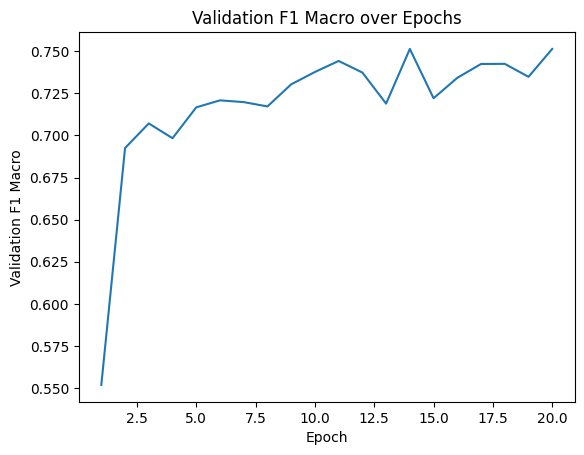

In [23]:
sns.lineplot(data=metrics_pl.to_pandas(), y="val_f1_macro", x=range(1, len(metrics_pl)+1))
plt.xlabel("Epoch")
plt.ylabel("Validation F1 Macro")
plt.title("Validation F1 Macro over Epochs")
plt.show()


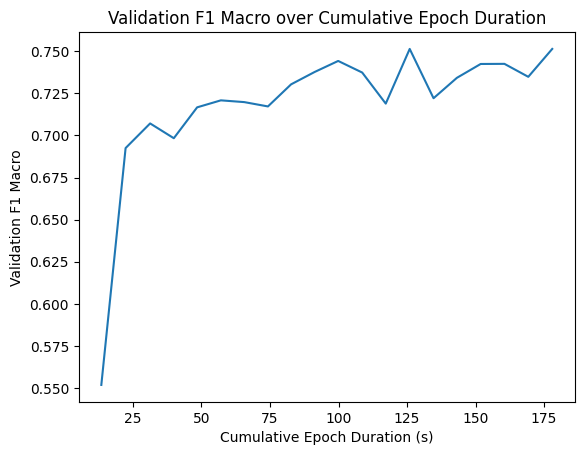

In [25]:
metrics_pl = metrics_pl.with_columns(pl.col("epoch_duration").cum_sum().alias("cumulative_epoch_duration"))
sns.lineplot(data=metrics_pl.to_pandas(), x="cumulative_epoch_duration", y="val_f1_macro")
plt.xlabel("Cumulative Epoch Duration (s)")
plt.ylabel("Validation F1 Macro")
plt.title("Validation F1 Macro over Cumulative Epoch Duration")
plt.show()

In [35]:
best_model.summary(expand_nested=True, show_trainable=True, line_length=200)


Model: "model_25"
___________________________________________________________________________________________________________________________________________________________________________________________________________________
 Layer (type)                                                                             Output Shape                                                                    Param #                       Trainable  
 input_26 (InputLayer)                                                                    [(None, 1)]                                                                     0                             Y          
                                                                                                                                                                                                                   
 text_vectorization (TextVectorization)                                                   (None, 15)                                  

In [113]:
logits = best_model.predict(test_pl[X].to_numpy())
labels = test_pl[y].to_numpy() 
compute_metrics(logits=logits, labels=labels)

382/382 [==============================] - 1s 1ms/step


/Users/unparagoned/Code/AI_L7/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


{'accuracy': 0.9163865890646774,
 'precision': 0.7278393942832735,
 'recall': 0.7773359625646814,
 'f1_macro': 0.7098724572164027}

In [ ]:
model, history= fit_base_model(model=model, params=params, epochs=15)

2026/03/11 13:56:36 WARNING mlflow.utils.validation: Param value '{0: 3.6188304351016214, 1: 3.6188304351016214, 2: 2.129482959314435, 3: 34.316495505274, 4: 1.022093...' (20224 characters) is truncated to 6000 characters to meet the length limit.


Epoch 1/15
382/382 [==============================] - 1s 4ms/step
 - val_f1_macro: 0.6733 - epoch_duration: 1.45s
77/77 [==============================] - 3s 39ms/step - loss: 0.0247 - accuracy: 0.9708 - val_loss: 0.1578 - val_accuracy: 0.9571 - val_f1_macro: 0.6733 - epoch_duration: 1.4508
Epoch 2/15
382/382 [==============================] - 1s 4ms/step
 - val_f1_macro: 0.6649 - epoch_duration: 1.67s
77/77 [==============================] - 3s 41ms/step - loss: 0.2823 - accuracy: 0.8905 - val_loss: 0.2044 - val_accuracy: 0.9331 - val_f1_macro: 0.6649 - epoch_duration: 1.6713
Epoch 3/15
382/382 [==============================] - 1s 4ms/step
 - val_f1_macro: 0.6821 - epoch_duration: 1.50s
77/77 [==============================] - 3s 39ms/step - loss: 0.1941 - accuracy: 0.8861 - val_loss: 0.2527 - val_accuracy: 0.9134 - val_f1_macro: 0.6821 - epoch_duration: 1.5048
Epoch 4/15
382/382 [==============================] - 2s 4ms/step
 - val_f1_macro: 0.6829 - epoch_duration: 1.57s
77/77 [===

2026/03/11 13:57:23 WARNING mlflow.utils.autologging_utils: Encountered unexpected error during tensorflow autologging: Changing param values is not allowed. Params were already logged='[{'key': 'epochs', 'old_value': '10', 'new_value': '15'}]' for run ID='732c8875e4a9493498b56d8e96d23967'.


In [ ]:
logits = model.predict(test_pl[X].to_numpy())
labels = test_pl[y].to_numpy() 
compute_metrics(logits=logits, labels=labels)

382/382 [==============================] - 2s 4ms/step


/Users/unparagoned/Code/AI_L7/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


{'accuracy': 0.911550127059595,
 'precision': 0.7122567710088188,
 'recall': 0.7689455404348818,
 'f1_macro': 0.7012695327228021}

In [50]:
model, history_pl = load_best_model(experiment_name=experiment_name, run_name=run_name)

TypeError: load_best_model() missing 1 required positional argument: 'vectorize'

# 4. CNN optimisation

In [ ]:
def create_cnn_model(trial: optuna.Trial | FixedTrial, vectorize: layers.TextVectorization) -> keras.Model:

    activation = trial.suggest_categorical("activation", ["relu", "gelu", "elu", "tanh"])
    c_activation = trial.suggest_categorical("c_activation", ["relu", "gelu", "elu", "tanh"])
    learning_rate = 1e-4
    dropout_rate = 0.254
    embedding_dim = trial.suggest_int("embedding_dim", 400, 1024)
    dense_units = trial.suggest_int("dense_units", 64, 350)
    num_units = trial.suggest_int("cnn_units", 64, 400)     
    kernel_size = 3

    inputs = keras.Input(shape=(1,), dtype = tf.string)
    x = vectorize(inputs)
    x = layers.Embedding(input_dim = max_tokens,
                        output_dim = embedding_dim,
                        mask_zero = False)(x)
    x = layers.SpatialDropout1D(dropout_rate)(x)
    
    x = layers.Conv1D(num_units, kernel_size=kernel_size, activation=c_activation)(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalMaxPooling1D()(x)
    x = layers.Dropout(dropout_rate)(x)
    x = layers.Dense(dense_units, activation=activation)(x)
    x = layers.Dropout(dropout_rate)(x)

    outputs = layers.Dense(num_classes, activation = 'softmax')(x)

    model = Model(inputs, outputs)
    model.compile(optimizer = keras.optimizers.AdamW(learning_rate=learning_rate, clipnorm=1.0),
                loss = 'sparse_categorical_crossentropy',
                metrics=['accuracy'])
    return model

def objective_cnn(
    trial: optuna.Trial, vectorize: layers.TextVectorization, epochs: int = 5
) -> float:

    model = None
    history = None
    val_f1_macro = None
    try:
        with mlflow.start_run(run_name=f"trial_{trial.number}", nested=True):
            batch_size = trial.suggest_categorical("batch_size", [16, 32, 64, 128])
            model = create_cnn_model(trial, vectorize=vectorize)
            train_ds, val_ds = create_datasets(batch_size)
            mlflow.log_params(trial.params)
            f1_callback = F1MacroCallback(validation_data=val_ds)
            train_start_time = time.time()
            history = model.fit(
                train_ds,
                validation_data=val_ds,
                epochs=epochs,
                class_weight=class_weights,
                batch_size=batch_size,
                callbacks=[
                    f1_callback,
                    keras.callbacks.EarlyStopping(
                        monitor="val_f1_macro",
                        mode="max",
                        patience=5,
                        restore_best_weights=True,
                    ),
                ],
            )
            val_f1_macro = max(history.history["val_f1_macro"])
            train_end_time = time.time()
            mlflow.log_metric("train_duration", train_end_time - train_start_time)
    finally:
        try:
            del train_ds
        except NameError:
            pass
        try:
            del val_ds
        except NameError:
            pass
        try:
            del history
        except NameError:
            pass
        try:
            f1_callback.cleanup()
            del f1_callback
        except NameError:
            pass
        try:
            if hasattr(model, 'optimizer'):
                model.optimizer = None
            del model
        except NameError:
            pass
        tf.keras.backend.clear_session()
        # Might need to run multiple times
        for i in range(5):
            gc.collect()

    return val_f1_macro

In [56]:
run_name = f"candidate_v3.{subset.label}"

In [25]:
with mlflow.start_run(run_name=run_name) as parent_run:
    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=SEED),
        pruner=optuna.pruners.MedianPruner(),
        study_name=run_name,
        storage="sqlite:///optuna.db",
        load_if_exists=True
    )
    global_start_time = datetime.now()
    # n_trails is how many more trials to run not total
    study.optimize(lambda trial: objective_cnn(trial=trial, vectorize=vectorize, epochs=25), n_trials=25, gc_after_trial=True)
    global_end_time = datetime.now()
    print(f"Total duration {(global_end_time - global_start_time).total_seconds()}s")
    print(f"Best trail: {study.best_trial.params}")

[I 2026-03-12 20:49:09,271] Using an existing study with name 'candidate_v3.sample_1_pct' instead of creating a new one.
2026/03/12 20:49:09 WARNING mlflow.utils.validation: Param value '{0: 3.6188304351016214, 1: 3.6188304351016214, 2: 2.129482959314435, 3: 34.316495505274, 4: 1.022093...' (20224 characters) is truncated to 6000 characters to meet the length limit.
2026/03/12 20:49:09 WARNING mlflow.tensorflow: Failed to log training dataset information to MLflow Tracking. Reason: 'ascii' codec can't decode byte 0xc2 in position 32: ordinal not in range(128)


Epoch 1/25


2026-03-12 20:49:09.805664: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


24/24 [==============================] - 0s 7ms/step - loss: 0.6982 - accuracy: 
 - val_f1_macro: 0.6030 - epoch_duration: 23.67s


/Users/unparagoned/Code/AI_L7/.venv/lib/python3.10/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(
2026/03/12 20:49:33 WARNING mlflow.utils.autologging_utils: Encountered unexpected error during autologging: Save or restore weights that is not an instance of `tf.Variable` is not supported in h5, use `save_format='tf'` instead. Received a model or layer TextVectorization with weights [<keras.src.layers.preprocessing.index_lookup.VocabWeightHandler object at 0x173b5c0d0>]


...

 - val_f1_macro: 0.7385 - epoch_duration: 12.34s
610/610 [==============================] - 12s 20ms/step - loss: 0.0914 - accuracy: 0.9550 - val_loss: 0.1280 - val_accuracy: 0.9614 - val_f1_macro: 0.7385 - epoch_duration: 12.3447
Epoch 18/25
24/24 [==============================] - 0s 3ms/step loss: 0.0925 - accuracy: 0.
 - val_f1_macro: 0.7391 - epoch_duration: 12.59s
610/610 [==============================] - 13s 21ms/step - loss: 0.0925 - accuracy: 0.9585 - val_loss: 0.1350 - val_accuracy: 0.9443 - val_f1_macro: 0.7391 - epoch_duration: 12.5910
Epoch 19/25
24/24 [==============================] - 0s 3ms/step loss: 0.0818 - accuracy: 0.
 - val_f1_macro: 0.7272 - epoch_duration: 12.37s
610/610 [==============================] - 12s 20ms/step - loss: 0.0817 - accuracy: 0.9536 - val_loss: 0.1399 - val_accuracy: 0.9434 - val_f1_macro: 0.7272 - epoch_duration: 12.3718
Epoch 20/25
24/24 [==============================] - 0s 3ms/step loss: 0.0863 - accuracy: 0.
 - val_f1_macro: 0.7325 - ep

2026/03/12 23:11:58 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


INFO:tensorflow:Assets written to: /var/folders/qf/z9b2_p1x6yv_5pw9rkgb9br40000gn/T/tmpy16sqczc/model/data/model/assets


INFO:tensorflow:Assets written to: /var/folders/qf/z9b2_p1x6yv_5pw9rkgb9br40000gn/T/tmpy16sqczc/model/data/model/assets
[I 2026-03-12 23:12:03,500] Trial 39 finished with value: 0.739126167730244 and parameters: {'batch_size': 32, 'activation': 'gelu', 'c_activation': 'gelu', 'embedding_dim': 629, 'dense_units': 128, 'cnn_units': 166}. Best is trial 27 with value: 0.7570690022750077.


Total duration 8574.323341s
Best trail: {'batch_size': 16, 'activation': 'gelu', 'c_activation': 'elu', 'embedding_dim': 518, 'dense_units': 88, 'cnn_units': 236}


The smaller batch sizes are much slower

In [34]:
study = optuna.load_study(
    study_name=run_name,
    storage="sqlite:///optuna.db",
)

In [26]:
optuna.visualization.plot_optimization_history(study)

In [ ]:
base_model, best_model, metrics, params = load_best_model(experiment_name=experiment_name, run_name=run_name, vectorize=vectorize)
metrics_pl = create_metric_dataframe(metrics=metrics)

Best run: trial_27


Best model params: {'batch_size': '16', 'activation': 'gelu', 'c_activation': 'elu', 'embedding_dim': '518', 'dense_units': '88', 'cnn_units': '236', 'epochs': '25', 'class_weight': '{0: 3.6188304351016214, 1: 3.6188304351016214, 2: 2.129482959314435, 3: 34.316495505274, 4: 1.0220934984453398, 5: 0.30245518275340266, 6: 0.13574316217872318, 7: 4.600208180213926, 8: 21.32525077827741, 9: 1492.7675544794188, 10: 746.3837772397094, 11: 995.1783696529459, 12: 746.3837772397094, 13: 26.656563472846766, 14: 2985.5351089588376, 15: 1492.7675544794188, 16: 9.50807359541031, 17: 2985.5351089588376, 18: 4.746478710586388, 19: 0.3978061437653348, 20: 1.9956785487692765, 21: 1.0217437060091847, 22: 5.312340051528181, 23: 746.3837772397094, 24: 2985.5351089588376, 25: 2985.5351089588376, 26: 2985.5351089588376, 27: 373.1918886198547, 28: 2985.5351089588376, 29: 20.73288270110304, 30: 2985.5351089588376, 31: 373.1918886198547, 32: 35.97030251757636, 33: 12.92439441107722, 34: 24.673843875692874, 35:

In [ ]:
params

{'batch_size': '16',
 'activation': 'gelu',
 'c_activation': 'elu',
 'embedding_dim': '518',
 'dense_units': '88',
 'cnn_units': '236',
 'epochs': '25',
 'class_weight': '{0: 3.6188304351016214, 1: 3.6188304351016214, 2: 2.129482959314435, 3: 34.316495505274, 4: 1.0220934984453398, 5: 0.30245518275340266, 6: 0.13574316217872318, 7: 4.600208180213926, 8: 21.32525077827741, 9: 1492.7675544794188, 10: 746.3837772397094, 11: 995.1783696529459, 12: 746.3837772397094, 13: 26.656563472846766, 14: 2985.5351089588376, 15: 1492.7675544794188, 16: 9.50807359541031, 17: 2985.5351089588376, 18: 4.746478710586388, 19: 0.3978061437653348, 20: 1.9956785487692765, 21: 1.0217437060091847, 22: 5.312340051528181, 23: 746.3837772397094, 24: 2985.5351089588376, 25: 2985.5351089588376, 26: 2985.5351089588376, 27: 373.1918886198547, 28: 2985.5351089588376, 29: 20.73288270110304, 30: 2985.5351089588376, 31: 373.1918886198547, 32: 35.97030251757636, 33: 12.92439441107722, 34: 24.673843875692874, 35: 52.37780892

In [36]:
metrics_pl

loss,accuracy,val_loss,val_accuracy,val_f1_macro,epoch_duration
f64,f64,f64,f64,f64,f64
0.831583,0.633639,0.819644,0.949914,0.489435,24.732242
0.421697,0.940058,0.28656,0.956636,0.638644,22.762956
0.275106,0.954506,0.192399,0.959751,0.699633,22.608823
0.193522,0.960193,0.169648,0.953275,0.7078,22.478291
0.154091,0.959322,0.147452,0.951389,0.726762,22.523521
…,…,…,…,…,…
0.10331,0.965828,0.111416,0.963522,0.743838,22.457499
0.102708,0.965521,0.117104,0.964669,0.748436,22.596011
0.095631,0.965162,0.112486,0.959997,0.743232,22.478777


In [28]:
logits = best_model.predict(test_pl[X].to_numpy())
labels = test_pl[y].to_numpy() 
compute_metrics(logits=logits, labels=labels)

382/382 [==============================] - 1s 3ms/step


/Users/unparagoned/Code/AI_L7/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


{'accuracy': 0.9700795147143209,
 'precision': 0.7655337296688606,
 'recall': 0.7799382073438416,
 'f1_macro': 0.7570690022750077}

In [38]:
results = test_model_over_populations(
    model=best_model,
    dataset_pl=dataset_test_pl,
)


## Bootstrap CI for test_5_pct

382/382 [==============================] - 1s 3ms/step


{'accuracy': {'mean': 0.9700795147143209,
  'confidence_interval': {'low': 0.9671284531518977,
   'high': 0.9729486023444545}},
 'f1_macro': {'mean': 0.7570690022750077,
  'confidence_interval': {'low': 0.7325970809199286,
   'high': 0.7745088375310998}},
 'f1_weighted': {'mean': 0.9655794245711496,
  'confidence_interval': {'low': 0.9623439604386466,
   'high': 0.9689190160323436}},
 'precision_macro': {'mean': 0.7655337296688606,
  'confidence_interval': {'low': 0.7372738336805286,
   'high': 0.7835879997414287}},
 'recall_macro': {'mean': 0.7799382073438416,
  'confidence_interval': {'low': 0.7582866817598343,
   'high': 0.8011642439661433}},
 'precision_weighted': {'mean': 0.9680749457234693,
  'confidence_interval': {'low': 0.9651156272437333,
   'high': 0.9719502628822548}},
 'recall_weighted': {'mean': 0.9700795147143209,
  'confidence_interval': {'low': 0.9671284531518977,
   'high': 0.9729486023444545}}}

## Bootstrap CI for holdout_10k

313/313 [==============================] - 1s 2ms/step


{'accuracy': {'mean': 0.971,
  'confidence_interval': {'low': 0.9677, 'high': 0.9742}},
 'f1_macro': {'mean': 0.7585930532293442,
  'confidence_interval': {'low': 0.7372392619528864,
   'high': 0.7919760746260031}},
 'f1_weighted': {'mean': 0.9668045232506891,
  'confidence_interval': {'low': 0.963045119560376,
   'high': 0.9705656375238909}},
 'precision_macro': {'mean': 0.768069030755871,
  'confidence_interval': {'low': 0.744898651737099,
   'high': 0.8039422161640506}},
 'recall_macro': {'mean': 0.7846796433916481,
  'confidence_interval': {'low': 0.7649230872754403,
   'high': 0.8219028774556832}},
 'precision_weighted': {'mean': 0.9704909389581088,
  'confidence_interval': {'low': 0.9664309980433403,
   'high': 0.9743005639188214}},
 'recall_weighted': {'mean': 0.971,
  'confidence_interval': {'low': 0.9677, 'high': 0.9742}}}

In [29]:
optuna.visualization.plot_slice(study)


- gelu had the best general activation
- elu had the best convolutional layer activation
- Batch size 16 had the best scores but was much slower
- Dense units had the best scores aroun 88
- Embedding dimension had bes scores around 518

## 4.1 Final CNN model

### 4.1.1 1% sqrt weighted train population

In [70]:
base_model, best_model, metrics, params = load_best_model(experiment_name=experiment_name, run_name="candidate_v3.sample_1_pct", vectorize=vectorize) 
metrics_pl = create_metric_dataframe(metrics=metrics)

Best run: trial_27


Best model params: {'batch_size': '16', 'activation': 'gelu', 'c_activation': 'elu', 'embedding_dim': '518', 'dense_units': '88', 'cnn_units': '236', 'epochs': '25', 'class_weight': '{0: 3.6188304351016214, 1: 3.6188304351016214, 2: 2.129482959314435, 3: 34.316495505274, 4: 1.0220934984453398, 5: 0.30245518275340266, 6: 0.13574316217872318, 7: 4.600208180213926, 8: 21.32525077827741, 9: 1492.7675544794188, 10: 746.3837772397094, 11: 995.1783696529459, 12: 746.3837772397094, 13: 26.656563472846766, 14: 2985.5351089588376, 15: 1492.7675544794188, 16: 9.50807359541031, 17: 2985.5351089588376, 18: 4.746478710586388, 19: 0.3978061437653348, 20: 1.9956785487692765, 21: 1.0217437060091847, 22: 5.312340051528181, 23: 746.3837772397094, 24: 2985.5351089588376, 25: 2985.5351089588376, 26: 2985.5351089588376, 27: 373.1918886198547, 28: 2985.5351089588376, 29: 20.73288270110304, 30: 2985.5351089588376, 31: 373.1918886198547, 32: 35.97030251757636, 33: 12.92439441107722, 34: 24.673843875692874, 35:

#### 4.1.1.1 Unweighted model

In [71]:
subset = DataSample.sample_1_pct_sqrt_weight 
train_pl = dataset_pl.filter(pl.col(subset.label))
test_pl = dataset_pl.filter(pl.col(test_col))
X_train = train_pl[X].to_numpy()
y_train = train_pl[y].to_numpy()
X_val = test_pl[X].to_numpy()
y_val = test_pl[y].to_numpy()

weighted = "unweighted"
model_path = f"data/nn/final_cnn_{weighted}_{subset.label}.keras"


In [72]:
def create_final_cnn_model(vectorize: layers.TextVectorization) -> keras.Model:

    activation = "gelu"
    c_activation = "elu"
    learning_rate = 1e-4
    dropout_rate = 0.254
    embedding_dim = 518
    dense_units = 88
    num_units = 236   
    kernel_size = 3

    inputs = keras.Input(shape=(1,), dtype = tf.string)
    x = vectorize(inputs)
    x = layers.Embedding(input_dim = max_tokens,
                        output_dim = embedding_dim,
                        mask_zero = False)(x)
    x = layers.SpatialDropout1D(dropout_rate)(x)
    
    x = layers.Conv1D(num_units, kernel_size=kernel_size, activation=c_activation)(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalMaxPooling1D()(x)
    x = layers.Dropout(dropout_rate)(x)
    x = layers.Dense(dense_units, activation=activation)(x)
    x = layers.Dropout(dropout_rate)(x)

    outputs = layers.Dense(num_classes, activation = 'softmax')(x)

    model = Model(inputs, outputs)
    model.compile(optimizer = keras.optimizers.AdamW(learning_rate=learning_rate, clipnorm=1.0),
                loss = 'sparse_categorical_crossentropy',
                metrics=['accuracy'])
    return model

In [73]:
model = create_final_cnn_model(vectorize=vectorize)
batch_size = int(params["batch_size"])
epochs = int(params["epochs"])
train_ds, val_ds = create_datasets(batch_size)
f1_callback = F1MacroCallback(validation_data=val_ds)
train_start_time = time.time()
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs,
    # class_weight=class_weights,
    batch_size=batch_size,
    callbacks=[
        f1_callback,
        keras.callbacks.EarlyStopping(
            monitor="val_f1_macro",
            mode="max",
            patience=5,
            restore_best_weights=True,
        ),
    ],
)

2026/05/31 22:20:31 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID 'cb54612ef97d4f1fb38fe36b3ff31292', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current tensorflow workflow
2026/05/31 22:20:31 WARNING mlflow.tensorflow: Failed to log training dataset information to MLflow Tracking. Reason: 'ascii' codec can't decode byte 0xc2 in position 32: ordinal not in range(128)


Epoch 1/25
477/477 [==============================] - 3s 6ms/step
 - val_f1_macro: 0.6971 - epoch_duration: 69.95s


/Users/unparagoned/Code/AI_L7/.venv/lib/python3.10/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(
2026/05/31 22:21:44 WARNING mlflow.utils.autologging_utils: Encountered unexpected error during autologging: Save or restore weights that is not an instance of `tf.Variable` is not supported in h5, use `save_format='tf'` instead. Received a model or layer TextVectorization with weights [<keras.src.layers.preprocessing.index_lookup.VocabWeightHandler object at 0x168435210>]


1220/1220 [==============================] - 73s 59ms/step - loss: 2.0099 - accuracy: 0.6683 - val_loss: 0.1916 - val_accuracy: 0.9649 - val_f1_macro: 0.6971 - epoch_duration: 69.9535
Epoch 2/25
477/477 [==============================] - 3s 6ms/step


/Users/unparagoned/Code/AI_L7/.venv/lib/python3.10/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(
2026/05/31 22:22:56 WARNING mlflow.utils.autologging_utils: Encountered unexpected error during autologging: Save or restore weights that is not an instance of `tf.Variable` is not supported in h5, use `save_format='tf'` instead. Received a model or layer TextVectorization with weights [<keras.src.layers.preprocessing.index_lookup.VocabWeightHandler object at 0x168435210>]


...

/Users/unparagoned/Code/AI_L7/.venv/lib/python3.10/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(
2026/05/31 22:24:10 WARNING mlflow.utils.autologging_utils: Encountered unexpected error during autologging: Save or restore weights that is not an instance of `tf.Variable` is not supported in h5, use `save_format='tf'` instead. Received a model or layer TextVectorization with weights [<keras.src.layers.preprocessing.index_lookup.VocabWeightHandler object at 0x168435210>]


1220/1220 [==============================] - 73s 60ms/step - loss: 0.3437 - accuracy: 0.8927 - val_loss: 0.0968 - val_accuracy: 0.9721 - val_f1_macro: 0.7667 - epoch_duration: 70.7115
Epoch 4/25
477/477 [==============================] - 3s 5ms/step
 - val_f1_macro: 0.7630 - epoch_duration: 69.08s


/Users/unparagoned/Code/AI_L7/.venv/lib/python3.10/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(
2026/05/31 22:25:22 WARNING mlflow.utils.autologging_utils: Encountered unexpected error during autologging: Save or restore weights that is not an instance of `tf.Variable` is not supported in h5, use `save_format='tf'` instead. Received a model or layer TextVectorization with weights [<keras.src.layers.preprocessing.index_lookup.VocabWeightHandler object at 0x168435210>]


1220/1220 [==============================] - 72s 59ms/step - loss: 0.3045 - accuracy: 0.8965 - val_loss: 0.0956 - val_accuracy: 0.9704 - val_f1_macro: 0.7630 - epoch_duration: 69.0796
Epoch 5/25
1217/1220 [============================>.] - ETA: 0s - loss: 0.2838 - accuracy: 0.9007

KeyboardInterrupt: 

In [ ]:
model.save(model_path)

In [ ]:
model = load_model(model_path)

In [ ]:
results = test_model_over_populations(model=model, dataset_pl=dataset_test_pl)
combined_results_pl = add_results_to_combined(results, combined_results_pl, subset, weighted)
display_wide(combined_results_pl)

## Bootstrap CI for test_5_pct

382/382 [==============================] - 1s 2ms/step


{'accuracy': {'mean': 0.9717189933601115,
  'confidence_interval': {'low': 0.9690118042462497,
   'high': 0.9746700549225347}},
 'f1_macro': {'mean': 0.7764499149585689,
  'confidence_interval': {'low': 0.7474943205559212,
   'high': 0.7939199680923891}},
 'f1_weighted': {'mean': 0.9669739725357106,
  'confidence_interval': {'low': 0.9637096434490322,
   'high': 0.9703778931267975}},
 'precision_macro': {'mean': 0.7986500924866939,
  'confidence_interval': {'low': 0.7599077519439696,
   'high': 0.8141171900424455}},
 'recall_macro': {'mean': 0.8008481351769035,
  'confidence_interval': {'low': 0.7756361685574299,
   'high': 0.8201057492156855}},
 'precision_weighted': {'mean': 0.9710823173975871,
  'confidence_interval': {'low': 0.9677088495224713,
   'high': 0.974585701446075}},
 'recall_weighted': {'mean': 0.9717189933601115,
  'confidence_interval': {'low': 0.9690118042462497,
   'high': 0.9746700549225347}}}

## Bootstrap CI for holdout_10k

313/313 [==============================] - 1s 2ms/step


{'accuracy': {'mean': 0.9739,
  'confidence_interval': {'low': 0.9709, 'high': 0.977}},
 'f1_macro': {'mean': 0.7965101390720667,
  'confidence_interval': {'low': 0.7740170047249567,
   'high': 0.8265467324346059}},
 'f1_weighted': {'mean': 0.9693020144243177,
  'confidence_interval': {'low': 0.9658700765761039,
   'high': 0.9729571196562917}},
 'precision_macro': {'mean': 0.8164681844048293,
  'confidence_interval': {'low': 0.7856338877016815,
   'high': 0.843806337230765}},
 'recall_macro': {'mean': 0.8160787783931703,
  'confidence_interval': {'low': 0.799181531372738,
   'high': 0.8490384673289477}},
 'precision_weighted': {'mean': 0.9740271535711741,
  'confidence_interval': {'low': 0.9688065897625717,
   'high': 0.9770125597955446}},
 'recall_weighted': {'mean': 0.9739,
  'confidence_interval': {'low': 0.9709, 'high': 0.977}}}

train_dataset,test_type,weighting,accuracy_mean,accuracy_confidence_interval_low,accuracy_confidence_interval_high,f1_macro_mean,f1_macro_confidence_interval_low,f1_macro_confidence_interval_high,f1_weighted_mean,f1_weighted_confidence_interval_low,f1_weighted_confidence_interval_high,precision_macro_mean,precision_macro_confidence_interval_low,precision_macro_confidence_interval_high,recall_macro_mean,recall_macro_confidence_interval_low,recall_macro_confidence_interval_high,precision_weighted_mean,precision_weighted_confidence_interval_low,precision_weighted_confidence_interval_high,recall_weighted_mean,recall_weighted_confidence_interval_low,recall_weighted_confidence_interval_high
str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""sample_1_pct_sqrt_weight""","""test_5_pct""","""unweighted""",0.971719,0.969012,0.97467,0.77645,0.747494,0.79392,0.966974,0.96371,0.970378,0.79865,0.759908,0.814117,0.800848,0.775636,0.820106,0.971082,0.967709,0.974586,0.971719,0.969012,0.97467
"""sample_1_pct_sqrt_weight""","""holdout_10k""","""unweighted""",0.9739,0.9709,0.977,0.79651,0.774017,0.826547,0.969302,0.96587,0.972957,0.816468,0.785634,0.843806,0.816079,0.799182,0.849038,0.974027,0.968807,0.977013,0.9739,0.9709,0.977


In [ ]:
logits = model.predict(test_pl[X].to_numpy())
labels = test_pl[y].to_numpy() 
compute_metrics(logits=logits, labels=labels)

382/382 [==============================] - 1s 2ms/step


/Users/unparagoned/Code/AI_L7/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


{'accuracy': 0.9741782113287974,
 'precision': 0.794693285460066,
 'recall': 0.795961573362114,
 'f1_macro': 0.7745234533211935}

Using the sqrt balanced dataset f1 macro score increased 1.4ppts from 0.757 to 0.771 and accuracy increased 0.1ppts

#### 4.1.1.2 Weighted model

In [ ]:
subset = DataSample.sample_1_pct_sqrt_weight 
weighted = "weighted"
test_col = "holdout"
train_pl = dataset_pl.filter(pl.col(subset.label))
test_pl = dataset_pl.filter(pl.col(test_col))
X_train = train_pl[X].to_numpy()
y_train = train_pl[y].to_numpy()
X_val = test_pl[X].to_numpy()
y_val = test_pl[y].to_numpy()
model_path = f"data/nn/final_cnn_{weighted}_{subset.label}.keras"

In [ ]:
model = create_final_cnn_model(vectorize=vectorize)
batch_size = int(params["batch_size"])
epochs = int(params["epochs"])
train_ds, val_ds = create_datasets(batch_size)
f1_callback = F1MacroCallback(validation_data=val_ds)
train_start_time = time.time()
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs,
    class_weight=class_weights,
    batch_size=batch_size,
    callbacks=[
        f1_callback,
        keras.callbacks.EarlyStopping(
            monitor="val_f1_macro",
            mode="max",
            patience=5,
            restore_best_weights=True,
        ),
    ],
)

2026/05/31 22:00:16 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID 'd5526f5642ed41c29e0e4e5dbd005b8b', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current tensorflow workflow
2026/05/31 22:00:16 WARNING mlflow.utils.validation: Param value '{0: 3.6188304351016214, 1: 3.6188304351016214, 2: 2.129482959314435, 3: 34.316495505274, 4: 1.022093...' (20224 characters) is truncated to 6000 characters to meet the length limit.
2026/05/31 22:00:16 WARNING mlflow.tensorflow: Failed to log training dataset information to MLflow Tracking. Reason: 'ascii' codec can't decode byte 0xc2 in position 32: ordinal not in range(128)


Epoch 1/25
477/477 [==============================] - 3s 6ms/step


/Users/unparagoned/Code/AI_L7/.venv/lib/python3.10/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(
2026/05/31 22:01:29 WARNING mlflow.utils.autologging_utils: Encountered unexpected error during autologging: Save or restore weights that is not an instance of `tf.Variable` is not supported in h5, use `save_format='tf'` instead. Received a model or layer TextVectorization with weights [<keras.src.layers.preprocessing.index_lookup.VocabWeightHandler object at 0x168435210>]


 - val_f1_macro: 0.5427 - epoch_duration: 70.08s
1220/1220 [==============================] - 73s 59ms/step - loss: 2.8222 - accuracy: 0.2183 - val_loss: 3.0071 - val_accuracy: 0.5360 - val_f1_macro: 0.5427 - epoch_duration: 70.0773
Epoch 2/25
477/477 [==============================] - 3s 6ms/step
 - val_f1_macro: 0.6661 - epoch_duration: 67.40s


/Users/unparagoned/Code/AI_L7/.venv/lib/python3.10/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(
2026/05/31 22:02:39 WARNING mlflow.utils.autologging_utils: Encountered unexpected error during autologging: Save or restore weights that is not an instance of `tf.Variable` is not supported in h5, use `save_format='tf'` instead. Received a model or layer TextVectorization with weights [<keras.src.layers.preprocessing.index_lookup.VocabWeightHandler object at 0x168435210>]


...

/Users/unparagoned/Code/AI_L7/.venv/lib/python3.10/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(
2026/05/31 22:16:54 WARNING mlflow.utils.autologging_utils: Encountered unexpected error during autologging: Save or restore weights that is not an instance of `tf.Variable` is not supported in h5, use `save_format='tf'` instead. Received a model or layer TextVectorization with weights [<keras.src.layers.preprocessing.index_lookup.VocabWeightHandler object at 0x168435210>]


1/1 [==============================] - 0s 23ms/step


2026/05/31 22:16:54 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


INFO:tensorflow:Assets written to: /var/folders/qf/z9b2_p1x6yv_5pw9rkgb9br40000gn/T/tmptei9jxb1/model/data/model/assets


INFO:tensorflow:Assets written to: /var/folders/qf/z9b2_p1x6yv_5pw9rkgb9br40000gn/T/tmptei9jxb1/model/data/model/assets


In [ ]:
model.save(model_path)

In [ ]:
model = load_model(model_path)

In [ ]:
results = test_model_over_populations(model=model, dataset_pl=dataset_test_pl)
combined_results_pl = add_results_to_combined(results, combined_results_pl, subset, weighted)
display_wide(combined_results_pl)

## Bootstrap CI for test_5_pct

382/382 [==============================] - 1s 2ms/step


{'accuracy': {'mean': 0.9104844659398311,
  'confidence_interval': {'low': 0.9053160095089762,
   'high': 0.9156508730223789}},
 'f1_macro': {'mean': 0.720745297933256,
  'confidence_interval': {'low': 0.6941798882947648,
   'high': 0.7370649108648348}},
 'f1_weighted': {'mean': 0.9154370068554918,
  'confidence_interval': {'low': 0.9100941659499496,
   'high': 0.9207627525617035}},
 'precision_macro': {'mean': 0.7432618254697658,
  'confidence_interval': {'low': 0.7082821777476835,
   'high': 0.7560113565269264}},
 'recall_macro': {'mean': 0.8024192773934951,
  'confidence_interval': {'low': 0.7758892307893815,
   'high': 0.8202774115338237}},
 'precision_weighted': {'mean': 0.963253305861254,
  'confidence_interval': {'low': 0.9565970721619247,
   'high': 0.9667330578544971}},
 'recall_weighted': {'mean': 0.9104844659398311,
  'confidence_interval': {'low': 0.9053160095089762,
   'high': 0.9156508730223789}}}

## Bootstrap CI for holdout_10k

313/313 [==============================] - 1s 2ms/step


{'accuracy': {'mean': 0.9193,
  'confidence_interval': {'low': 0.9139, 'high': 0.9247}},
 'f1_macro': {'mean': 0.7330404140411357,
  'confidence_interval': {'low': 0.7106680789575829,
   'high': 0.7582741682774676}},
 'f1_weighted': {'mean': 0.9243434993482269,
  'confidence_interval': {'low': 0.9191330511508431,
   'high': 0.9298842838417487}},
 'precision_macro': {'mean': 0.7597982014954485,
  'confidence_interval': {'low': 0.7263781151880009,
   'high': 0.7822543203278681}},
 'recall_macro': {'mean': 0.8074422714925735,
  'confidence_interval': {'low': 0.778840250238511,
   'high': 0.8348197029166274}},
 'precision_weighted': {'mean': 0.9694968747000523,
  'confidence_interval': {'low': 0.9600791014088028,
   'high': 0.9722351307100391}},
 'recall_weighted': {'mean': 0.9193,
  'confidence_interval': {'low': 0.9139, 'high': 0.9247}}}

train_dataset,test_type,weighting,accuracy_mean,accuracy_confidence_interval_low,accuracy_confidence_interval_high,f1_macro_mean,f1_macro_confidence_interval_low,f1_macro_confidence_interval_high,f1_weighted_mean,f1_weighted_confidence_interval_low,f1_weighted_confidence_interval_high,precision_macro_mean,precision_macro_confidence_interval_low,precision_macro_confidence_interval_high,recall_macro_mean,recall_macro_confidence_interval_low,recall_macro_confidence_interval_high,precision_weighted_mean,precision_weighted_confidence_interval_low,precision_weighted_confidence_interval_high,recall_weighted_mean,recall_weighted_confidence_interval_low,recall_weighted_confidence_interval_high
str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""sample_1_pct_sqrt_weight""","""test_5_pct""","""unweighted""",0.971719,0.969012,0.97467,0.77645,0.747494,0.79392,0.966974,0.96371,0.970378,0.79865,0.759908,0.814117,0.800848,0.775636,0.820106,0.971082,0.967709,0.974586,0.971719,0.969012,0.97467
"""sample_1_pct_sqrt_weight""","""holdout_10k""","""unweighted""",0.9739,0.9709,0.977,0.79651,0.774017,0.826547,0.969302,0.96587,0.972957,0.816468,0.785634,0.843806,0.816079,0.799182,0.849038,0.974027,0.968807,0.977013,0.9739,0.9709,0.977
"""sample_1_pct_sqrt_weight""","""test_5_pct""","""weighted""",0.910484,0.905316,0.915651,0.720745,0.69418,0.737065,0.915437,0.910094,0.920763,0.743262,0.708282,0.756011,0.802419,0.775889,0.820277,0.963253,0.956597,0.966733,0.910484,0.905316,0.915651
"""sample_1_pct_sqrt_weight""","""holdout_10k""","""weighted""",0.9193,0.9139,0.9247,0.73304,0.710668,0.758274,0.924343,0.919133,0.929884,0.759798,0.726378,0.782254,0.807442,0.77884,0.83482,0.969497,0.960079,0.972235,0.9193,0.9139,0.9247


In [ ]:
logits = model.predict(test_pl[X].to_numpy())
labels = test_pl[y].to_numpy() 
compute_metrics(logits=logits, labels=labels)

382/382 [==============================] - 1s 2ms/step


/Users/unparagoned/Code/AI_L7/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


{'accuracy': 0.9013853594556931,
 'precision': 0.760457444602522,
 'recall': 0.803666661035138,
 'f1_macro': 0.7190523647420346}

The weighted model had much worse scores 
- Accuracy(.0.910484 vs 0.0.971719) 
- f1_macro(0.720745 vs 0.77645)

### 4.1.1.3 Sqrt weighted model

In [77]:
sqrt_class_weights = {
    int(c): float(np.sqrt(w))
    for c, w in class_weights.items()
}

In [80]:
subset = DataSample.sample_1_pct_sqrt_weight 
weighted = "sqrt_weighted"
test_col = "holdout"
train_pl = dataset_pl.filter(pl.col(subset.label))
test_pl = dataset_pl.filter(pl.col(test_col))
X_train = train_pl[X].to_numpy()
y_train = train_pl[y].to_numpy()
X_val = test_pl[X].to_numpy()
y_val = test_pl[y].to_numpy()
model_path = f"data/nn/final_cnn_{weighted}_{subset.label}.keras"

In [81]:
model = create_final_cnn_model(vectorize=vectorize)
batch_size = int(params["batch_size"])
epochs = int(params["epochs"])
train_ds, val_ds = create_datasets(batch_size)
f1_callback = F1MacroCallback(validation_data=val_ds)
train_start_time = time.time()
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs,
    class_weight=sqrt_class_weights,
    batch_size=batch_size,
    callbacks=[
        f1_callback,
        keras.callbacks.EarlyStopping(
            monitor="val_f1_macro",
            mode="max",
            patience=5,
            restore_best_weights=True,
        ),
    ],
)

2026/05/31 22:31:21 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '3d7f41ef36c94d80afb112957eb2e6c5', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current tensorflow workflow
2026/05/31 22:31:21 WARNING mlflow.utils.validation: Param value '{0: 1.9023223793830586, 1: 1.9023223793830586, 2: 1.459274805961658, 3: 5.858028295021628, 4: 1.0109...' (19998 characters) is truncated to 6000 characters to meet the length limit.
2026/05/31 22:31:21 WARNING mlflow.tensorflow: Failed to log training dataset information to MLflow Tracking. Reason: 'ascii' codec can't decode byte 0xc2 in position 32: ordinal not in range(128)


Epoch 1/25
477/477 [==============================] - 3s 6ms/step


/Users/unparagoned/Code/AI_L7/.venv/lib/python3.10/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(
2026/05/31 22:32:37 WARNING mlflow.utils.autologging_utils: Encountered unexpected error during autologging: Save or restore weights that is not an instance of `tf.Variable` is not supported in h5, use `save_format='tf'` instead. Received a model or layer TextVectorization with weights [<keras.src.layers.preprocessing.index_lookup.VocabWeightHandler object at 0x168435210>]


 - val_f1_macro: 0.6849 - epoch_duration: 73.35s
1220/1220 [==============================] - 76s 62ms/step - loss: 2.0056 - accuracy: 0.5650 - val_loss: 0.5638 - val_accuracy: 0.9439 - val_f1_macro: 0.6849 - epoch_duration: 73.3462
Epoch 2/25
477/477 [==============================] - 2s 5ms/step
 - val_f1_macro: 0.7381 - epoch_duration: 69.71s


/Users/unparagoned/Code/AI_L7/.venv/lib/python3.10/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(
2026/05/31 22:33:50 WARNING mlflow.utils.autologging_utils: Encountered unexpected error during autologging: Save or restore weights that is not an instance of `tf.Variable` is not supported in h5, use `save_format='tf'` instead. Received a model or layer TextVectorization with weights [<keras.src.layers.preprocessing.index_lookup.VocabWeightHandler object at 0x168435210>]


...

/Users/unparagoned/Code/AI_L7/.venv/lib/python3.10/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(
2026/05/31 22:52:39 WARNING mlflow.utils.autologging_utils: Encountered unexpected error during autologging: Save or restore weights that is not an instance of `tf.Variable` is not supported in h5, use `save_format='tf'` instead. Received a model or layer TextVectorization with weights [<keras.src.layers.preprocessing.index_lookup.VocabWeightHandler object at 0x168435210>]


1220/1220 [==============================] - 71s 58ms/step - loss: 0.2806 - accuracy: 0.8931 - val_loss: 0.1107 - val_accuracy: 0.9642 - val_f1_macro: 0.7611 - epoch_duration: 67.9302
Epoch 19/25
477/477 [==============================] - 3s 6ms/step
 - val_f1_macro: 0.7675 - epoch_duration: 68.61s
1220/1220 [==============================] - 72s 59ms/step - loss: 0.2756 - accuracy: 0.8984 - val_loss: 0.1147 - val_accuracy: 0.9644 - val_f1_macro: 0.7675 - epoch_duration: 68.6140
Epoch 20/25
477/477 [==============================] - 3s 6ms/step
 - val_f1_macro: 0.7585 - epoch_duration: 67.91s
1220/1220 [==============================] - 71s 58ms/step - loss: 0.2781 - accuracy: 0.8962 - val_loss: 0.1163 - val_accuracy: 0.9617 - val_f1_macro: 0.7585 - epoch_duration: 67.9109
Epoch 21/25
477/477 [==============================] - 3s 5ms/step
 - val_f1_macro: 0.7456 - epoch_duration: 68.47s
1220/1220 [==============================] - 71s 58ms/step - loss: 0.2730 - accuracy: 0.8996 - val_l

2026/05/31 22:59:46 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


INFO:tensorflow:Assets written to: /var/folders/qf/z9b2_p1x6yv_5pw9rkgb9br40000gn/T/tmpjyhd65g1/model/data/model/assets


INFO:tensorflow:Assets written to: /var/folders/qf/z9b2_p1x6yv_5pw9rkgb9br40000gn/T/tmpjyhd65g1/model/data/model/assets


In [82]:
model.save(model_path)

In [83]:
results = test_model_over_populations(model=model, dataset_pl=dataset_test_pl)
combined_results_pl = add_results_to_combined(results, combined_results_pl, subset, weighted)
display_wide(combined_results_pl)

## Bootstrap CI for test_5_pct

382/382 [==============================] - 1s 2ms/step


{'accuracy': {'mean': 0.9632756783342897,
  'confidence_interval': {'low': 0.960242642839577,
   'high': 0.9663906877612919}},
 'f1_macro': {'mean': 0.7649325453343193,
  'confidence_interval': {'low': 0.739329646872114,
   'high': 0.7851185013867384}},
 'f1_weighted': {'mean': 0.9611940384843656,
  'confidence_interval': {'low': 0.9579291136159909,
   'high': 0.9648357441673739}},
 'precision_macro': {'mean': 0.7815887809102463,
  'confidence_interval': {'low': 0.7485115759565837,
   'high': 0.7994853385593556}},
 'recall_macro': {'mean': 0.8057884229236558,
  'confidence_interval': {'low': 0.7813180574567987,
   'high': 0.8278449358244968}},
 'precision_weighted': {'mean': 0.9708236963689716,
  'confidence_interval': {'low': 0.967812376538798,
   'high': 0.9743595852476955}},
 'recall_weighted': {'mean': 0.9632756783342897,
  'confidence_interval': {'low': 0.960242642839577,
   'high': 0.9663906877612919}}}

## Bootstrap CI for holdout_10k

313/313 [==============================] - 1s 2ms/step


{'accuracy': {'mean': 0.965,
  'confidence_interval': {'low': 0.9613975, 'high': 0.9682}},
 'f1_macro': {'mean': 0.7859609058049533,
  'confidence_interval': {'low': 0.7640688321543844,
   'high': 0.814111618461818}},
 'f1_weighted': {'mean': 0.9637641547707646,
  'confidence_interval': {'low': 0.9600621289041263,
   'high': 0.9672779664951364}},
 'precision_macro': {'mean': 0.8071743707848368,
  'confidence_interval': {'low': 0.775659495557361,
   'high': 0.8314084012732647}},
 'recall_macro': {'mean': 0.8181769527686849,
  'confidence_interval': {'low': 0.8000344711036292,
   'high': 0.8502735515787173}},
 'precision_weighted': {'mean': 0.9743332232831228,
  'confidence_interval': {'low': 0.9692331568684326,
   'high': 0.9770203461625635}},
 'recall_weighted': {'mean': 0.965,
  'confidence_interval': {'low': 0.9613975, 'high': 0.9682}}}

train_dataset,test_type,weighting,accuracy_mean,accuracy_confidence_interval_low,accuracy_confidence_interval_high,f1_macro_mean,f1_macro_confidence_interval_low,f1_macro_confidence_interval_high,f1_weighted_mean,f1_weighted_confidence_interval_low,f1_weighted_confidence_interval_high,precision_macro_mean,precision_macro_confidence_interval_low,precision_macro_confidence_interval_high,recall_macro_mean,recall_macro_confidence_interval_low,recall_macro_confidence_interval_high,precision_weighted_mean,precision_weighted_confidence_interval_low,precision_weighted_confidence_interval_high,recall_weighted_mean,recall_weighted_confidence_interval_low,recall_weighted_confidence_interval_high
str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""sample_1_pct_sqrt_weight""","""test_5_pct""","""unweighted""",0.971719,0.969012,0.97467,0.77645,0.747494,0.79392,0.966974,0.96371,0.970378,0.79865,0.759908,0.814117,0.800848,0.775636,0.820106,0.971082,0.967709,0.974586,0.971719,0.969012,0.97467
"""sample_1_pct_sqrt_weight""","""holdout_10k""","""unweighted""",0.9739,0.9709,0.977,0.79651,0.774017,0.826547,0.969302,0.96587,0.972957,0.816468,0.785634,0.843806,0.816079,0.799182,0.849038,0.974027,0.968807,0.977013,0.9739,0.9709,0.977
"""sample_1_pct_sqrt_weight""","""test_5_pct""","""weighted""",0.910484,0.905316,0.915651,0.720745,0.69418,0.737065,0.915437,0.910094,0.920763,0.743262,0.708282,0.756011,0.802419,0.775889,0.820277,0.963253,0.956597,0.966733,0.910484,0.905316,0.915651
"""sample_1_pct_sqrt_weight""","""holdout_10k""","""weighted""",0.9193,0.9139,0.9247,0.73304,0.710668,0.758274,0.924343,0.919133,0.929884,0.759798,0.726378,0.782254,0.807442,0.77884,0.83482,0.969497,0.960079,0.972235,0.9193,0.9139,0.9247
"""sample_1_pct_sqrt_weight""","""test_5_pct""","""sqrt_weighted""",0.963276,0.960243,0.966391,0.764933,0.73933,0.785119,0.961194,0.957929,0.964836,0.781589,0.748512,0.799485,0.805788,0.781318,0.827845,0.970824,0.967812,0.97436,0.963276,0.960243,0.966391
"""sample_1_pct_sqrt_weight""","""holdout_10k""","""sqrt_weighted""",0.965,0.9613975,0.9682,0.785961,0.764069,0.814112,0.963764,0.960062,0.967278,0.807174,0.775659,0.831408,0.818177,0.800034,0.850274,0.974333,0.969233,0.97702,0.965,0.9613975,0.9682


In [ ]:
results = test_model_over_populations(model=model, dataset_pl=dataset_test_pl)
combined_results_pl = add_results_to_combined(results, combined_results_pl, subset, weighted)
display_wide(combined_results_pl)

Using sqrt weightings improved the accuracy and f1-macro but still not as good as unweighted model. Maybe the combo of weighted data and weighted wieghtings isn't great.



### 4.1.2 1% train population

#### 4.1.2.1 Sqrt weighted model

In [84]:
subset = DataSample.sample_1_pct 
weighted = "sqrt_weighted"
test_col = "holdout"
train_pl = dataset_pl.filter(pl.col(subset.label))
test_pl = dataset_pl.filter(pl.col(test_col))
X_train = train_pl[X].to_numpy()
y_train = train_pl[y].to_numpy()
X_val = test_pl[X].to_numpy()
y_val = test_pl[y].to_numpy()
model_path = f"data/nn/final_cnn_{weighted}_{subset.label}.keras"

In [85]:
model = create_final_cnn_model(vectorize=vectorize)
batch_size = int(params["batch_size"])
epochs = int(params["epochs"])
train_ds, val_ds = create_datasets(batch_size)
f1_callback = F1MacroCallback(validation_data=val_ds)
train_start_time = time.time()
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs,
    class_weight=sqrt_class_weights,
    batch_size=batch_size,
    callbacks=[
        f1_callback,
        keras.callbacks.EarlyStopping(
            monitor="val_f1_macro",
            mode="max",
            patience=5,
            restore_best_weights=True,
        ),
    ],
)

2026/06/01 02:27:40 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID 'e4e5449d13ef49f6b3064dca567f9651', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current tensorflow workflow
2026/06/01 02:27:40 WARNING mlflow.utils.validation: Param value '{0: 1.9023223793830586, 1: 1.9023223793830586, 2: 1.459274805961658, 3: 5.858028295021628, 4: 1.0109...' (19998 characters) is truncated to 6000 characters to meet the length limit.
2026/06/01 02:27:40 WARNING mlflow.tensorflow: Failed to log training dataset information to MLflow Tracking. Reason: 'ascii' codec can't decode byte 0xc2 in position 32: ordinal not in range(128)


Epoch 1/25
477/477 [==============================] - 3s 6ms/step


/Users/unparagoned/Code/AI_L7/.venv/lib/python3.10/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(
2026/06/01 02:28:55 WARNING mlflow.utils.autologging_utils: Encountered unexpected error during autologging: Save or restore weights that is not an instance of `tf.Variable` is not supported in h5, use `save_format='tf'` instead. Received a model or layer TextVectorization with weights [<keras.src.layers.preprocessing.index_lookup.VocabWeightHandler object at 0x168435210>]


 - val_f1_macro: 0.4796 - epoch_duration: 71.57s
1220/1220 [==============================] - 75s 61ms/step - loss: 0.7128 - accuracy: 0.8090 - val_loss: 0.3202 - val_accuracy: 0.9562 - val_f1_macro: 0.4796 - epoch_duration: 71.5748
Epoch 2/25
477/477 [==============================] - 3s 6ms/step


/Users/unparagoned/Code/AI_L7/.venv/lib/python3.10/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(
2026/06/01 02:30:07 WARNING mlflow.utils.autologging_utils: Encountered unexpected error during autologging: Save or restore weights that is not an instance of `tf.Variable` is not supported in h5, use `save_format='tf'` instead. Received a model or layer TextVectorization with weights [<keras.src.layers.preprocessing.index_lookup.VocabWeightHandler object at 0x168435210>]


...

/Users/unparagoned/Code/AI_L7/.venv/lib/python3.10/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(
2026/06/01 02:48:35 WARNING mlflow.utils.autologging_utils: Encountered unexpected error during autologging: Save or restore weights that is not an instance of `tf.Variable` is not supported in h5, use `save_format='tf'` instead. Received a model or layer TextVectorization with weights [<keras.src.layers.preprocessing.index_lookup.VocabWeightHandler object at 0x168435210>]


 - val_f1_macro: 0.7481 - epoch_duration: 71.09s
1220/1220 [==============================] - 74s 61ms/step - loss: 0.0719 - accuracy: 0.9738 - val_loss: 0.0906 - val_accuracy: 0.9740 - val_f1_macro: 0.7481 - epoch_duration: 71.0889
Epoch 18/25
477/477 [==============================] - 3s 6ms/step
 - val_f1_macro: 0.7502 - epoch_duration: 72.02s
1220/1220 [==============================] - 75s 62ms/step - loss: 0.0712 - accuracy: 0.9730 - val_loss: 0.0932 - val_accuracy: 0.9732 - val_f1_macro: 0.7502 - epoch_duration: 72.0213
Epoch 19/25
477/477 [==============================] - 2s 5ms/step
 - val_f1_macro: 0.7455 - epoch_duration: 72.14s
1220/1220 [==============================] - 75s 61ms/step - loss: 0.0696 - accuracy: 0.9736 - val_loss: 0.0926 - val_accuracy: 0.9730 - val_f1_macro: 0.7455 - epoch_duration: 72.1354
Epoch 20/25
477/477 [==============================] - 3s 5ms/step
 - val_f1_macro: 0.7503 - epoch_duration: 71.52s
1/1 [==============================] - 0s 36ms/step

2026/06/01 02:52:20 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


INFO:tensorflow:Assets written to: /var/folders/qf/z9b2_p1x6yv_5pw9rkgb9br40000gn/T/tmpnog8464w/model/data/model/assets


INFO:tensorflow:Assets written to: /var/folders/qf/z9b2_p1x6yv_5pw9rkgb9br40000gn/T/tmpnog8464w/model/data/model/assets


In [86]:
model.save(model_path)

In [87]:
results = test_model_over_populations(model=model, dataset_pl=dataset_test_pl)
combined_results_pl = add_results_to_combined(results, combined_results_pl, subset, weighted)
display_wide(combined_results_pl)

## Bootstrap CI for test_5_pct

382/382 [==============================] - 1s 2ms/step


{'accuracy': {'mean': 0.972866628412165,
  'confidence_interval': {'low': 0.9700795147143209,
   'high': 0.9758176899745881}},
 'f1_macro': {'mean': 0.754122742522719,
  'confidence_interval': {'low': 0.7280615383003806,
   'high': 0.7746697193211779}},
 'f1_weighted': {'mean': 0.967304842373412,
  'confidence_interval': {'low': 0.9640962678415683,
   'high': 0.970759571938605}},
 'precision_macro': {'mean': 0.7633594117668442,
  'confidence_interval': {'low': 0.7321031966384486,
   'high': 0.7817950102150087}},
 'recall_macro': {'mean': 0.7787172505300168,
  'confidence_interval': {'low': 0.7599424783684575,
   'high': 0.8013734268973114}},
 'precision_weighted': {'mean': 0.9688639915663112,
  'confidence_interval': {'low': 0.9657858751797195,
   'high': 0.9726586118651604}},
 'recall_weighted': {'mean': 0.972866628412165,
  'confidence_interval': {'low': 0.9700795147143209,
   'high': 0.9758176899745881}}}

## Bootstrap CI for holdout_10k

313/313 [==============================] - 1s 2ms/step


{'accuracy': {'mean': 0.9736,
  'confidence_interval': {'low': 0.9703, 'high': 0.9766}},
 'f1_macro': {'mean': 0.7634891943705039,
  'confidence_interval': {'low': 0.7418700532511753,
   'high': 0.796168742972301}},
 'f1_weighted': {'mean': 0.9683820317148158,
  'confidence_interval': {'low': 0.9645273006044319,
   'high': 0.971911286850896}},
 'precision_macro': {'mean': 0.7827312884077402,
  'confidence_interval': {'low': 0.7529526923260097,
   'high': 0.8136734976559283}},
 'recall_macro': {'mean': 0.7790585398468775,
  'confidence_interval': {'low': 0.7631876337759028,
   'high': 0.8160413433240467}},
 'precision_weighted': {'mean': 0.9699125291721536,
  'confidence_interval': {'low': 0.9660948107597616,
   'high': 0.9738719730276044}},
 'recall_weighted': {'mean': 0.9736,
  'confidence_interval': {'low': 0.9703, 'high': 0.9766}}}

train_dataset,test_type,weighting,accuracy_mean,accuracy_confidence_interval_low,accuracy_confidence_interval_high,f1_macro_mean,f1_macro_confidence_interval_low,f1_macro_confidence_interval_high,f1_weighted_mean,f1_weighted_confidence_interval_low,f1_weighted_confidence_interval_high,precision_macro_mean,precision_macro_confidence_interval_low,precision_macro_confidence_interval_high,recall_macro_mean,recall_macro_confidence_interval_low,recall_macro_confidence_interval_high,precision_weighted_mean,precision_weighted_confidence_interval_low,precision_weighted_confidence_interval_high,recall_weighted_mean,recall_weighted_confidence_interval_low,recall_weighted_confidence_interval_high
str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""sample_1_pct_sqrt_weight""","""test_5_pct""","""unweighted""",0.971719,0.969012,0.97467,0.77645,0.747494,0.79392,0.966974,0.96371,0.970378,0.79865,0.759908,0.814117,0.800848,0.775636,0.820106,0.971082,0.967709,0.974586,0.971719,0.969012,0.97467
"""sample_1_pct_sqrt_weight""","""holdout_10k""","""unweighted""",0.9739,0.9709,0.977,0.79651,0.774017,0.826547,0.969302,0.96587,0.972957,0.816468,0.785634,0.843806,0.816079,0.799182,0.849038,0.974027,0.968807,0.977013,0.9739,0.9709,0.977
"""sample_1_pct_sqrt_weight""","""test_5_pct""","""weighted""",0.910484,0.905316,0.915651,0.720745,0.69418,0.737065,0.915437,0.910094,0.920763,0.743262,0.708282,0.756011,0.802419,0.775889,0.820277,0.963253,0.956597,0.966733,0.910484,0.905316,0.915651
"""sample_1_pct_sqrt_weight""","""holdout_10k""","""weighted""",0.9193,0.9139,0.9247,0.73304,0.710668,0.758274,0.924343,0.919133,0.929884,0.759798,0.726378,0.782254,0.807442,0.77884,0.83482,0.969497,0.960079,0.972235,0.9193,0.9139,0.9247
"""sample_1_pct_sqrt_weight""","""test_5_pct""","""sqrt_weighted""",0.963276,0.960243,0.966391,0.764933,0.73933,0.785119,0.961194,0.957929,0.964836,0.781589,0.748512,0.799485,0.805788,0.781318,0.827845,0.970824,0.967812,0.97436,0.963276,0.960243,0.966391
"""sample_1_pct_sqrt_weight""","""holdout_10k""","""sqrt_weighted""",0.965,0.9613975,0.9682,0.785961,0.764069,0.814112,0.963764,0.960062,0.967278,0.807174,0.775659,0.831408,0.818177,0.800034,0.850274,0.974333,0.969233,0.97702,0.965,0.9613975,0.9682
"""sample_1_pct""","""test_5_pct""","""sqrt_weighted""",0.972867,0.97008,0.975818,0.754123,0.728062,0.77467,0.967305,0.964096,0.97076,0.763359,0.732103,0.781795,0.778717,0.759942,0.801373,0.968864,0.965786,0.972659,0.972867,0.97008,0.975818
"""sample_1_pct""","""holdout_10k""","""sqrt_weighted""",0.9736,0.9703,0.9766,0.763489,0.74187,0.796169,0.968382,0.964527,0.971911,0.782731,0.752953,0.813673,0.779059,0.763188,0.816041,0.969913,0.966095,0.973872,0.9736,0.9703,0.9766


#### 4.1.2.2 Weighted model

In [89]:
subset = DataSample.sample_1_pct 
weighted = "weighted"
test_col = "holdout"
train_pl = dataset_pl.filter(pl.col(subset.label))
test_pl = dataset_pl.filter(pl.col(test_col))
X_train = train_pl[X].to_numpy()
y_train = train_pl[y].to_numpy()
X_val = test_pl[X].to_numpy()
y_val = test_pl[y].to_numpy()
model_path = f"data/nn/final_cnn_{weighted}_{subset.label}.keras"

In [90]:
model = create_final_cnn_model(vectorize=vectorize)
batch_size = int(params["batch_size"])
epochs = int(params["epochs"])
train_ds, val_ds = create_datasets(batch_size)
f1_callback = F1MacroCallback(validation_data=val_ds)
train_start_time = time.time()
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs,
    class_weight=class_weights,
    batch_size=batch_size,
    callbacks=[
        f1_callback,
        keras.callbacks.EarlyStopping(
            monitor="val_f1_macro",
            mode="max",
            patience=5,
            restore_best_weights=True,
        ),
    ],
)
model.save(model_path)

2026/06/01 02:58:04 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '11a94b4d1bb3454ab6c03f09147a8e46', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current tensorflow workflow
2026/06/01 02:58:04 WARNING mlflow.utils.validation: Param value '{0: 3.6188304351016214, 1: 3.6188304351016214, 2: 2.129482959314435, 3: 34.316495505274, 4: 1.022093...' (20224 characters) is truncated to 6000 characters to meet the length limit.
2026/06/01 02:58:04 WARNING mlflow.tensorflow: Failed to log training dataset information to MLflow Tracking. Reason: 'ascii' codec can't decode byte 0xc2 in position 32: ordinal not in range(128)


Epoch 1/25
477/477 [==============================] - 3s 6ms/step
 - val_f1_macro: 0.4800 - epoch_duration: 72.31s


/Users/unparagoned/Code/AI_L7/.venv/lib/python3.10/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(
2026/06/01 02:59:19 WARNING mlflow.utils.autologging_utils: Encountered unexpected error during autologging: Save or restore weights that is not an instance of `tf.Variable` is not supported in h5, use `save_format='tf'` instead. Received a model or layer TextVectorization with weights [<keras.src.layers.preprocessing.index_lookup.VocabWeightHandler object at 0x168435210>]


1220/1220 [==============================] - 75s 61ms/step - loss: 0.8278 - accuracy: 0.6547 - val_loss: 0.8598 - val_accuracy: 0.9395 - val_f1_macro: 0.4800 - epoch_duration: 72.3125
Epoch 2/25
477/477 [==============================] - 3s 6ms/step
 - val_f1_macro: 0.6466 - epoch_duration: 71.73s


/Users/unparagoned/Code/AI_L7/.venv/lib/python3.10/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(
2026/06/01 03:00:34 WARNING mlflow.utils.autologging_utils: Encountered unexpected error during autologging: Save or restore weights that is not an instance of `tf.Variable` is not supported in h5, use `save_format='tf'` instead. Received a model or layer TextVectorization with weights [<keras.src.layers.preprocessing.index_lookup.VocabWeightHandler object at 0x168435210>]


...

/Users/unparagoned/Code/AI_L7/.venv/lib/python3.10/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(
2026/06/01 03:18:56 WARNING mlflow.utils.autologging_utils: Encountered unexpected error during autologging: Save or restore weights that is not an instance of `tf.Variable` is not supported in h5, use `save_format='tf'` instead. Received a model or layer TextVectorization with weights [<keras.src.layers.preprocessing.index_lookup.VocabWeightHandler object at 0x168435210>]


 - val_f1_macro: 0.7446 - epoch_duration: 69.18s
1220/1220 [==============================] - 72s 59ms/step - loss: 0.0931 - accuracy: 0.9669 - val_loss: 0.1065 - val_accuracy: 0.9649 - val_f1_macro: 0.7446 - epoch_duration: 69.1820
Epoch 18/25
477/477 [==============================] - 3s 6ms/step
 - val_f1_macro: 0.7531 - epoch_duration: 72.40s
1220/1220 [==============================] - 76s 62ms/step - loss: 0.0955 - accuracy: 0.9656 - val_loss: 0.1117 - val_accuracy: 0.9708 - val_f1_macro: 0.7531 - epoch_duration: 72.4042
Epoch 19/25
477/477 [==============================] - 3s 5ms/step
 - val_f1_macro: 0.7531 - epoch_duration: 72.57s
1220/1220 [==============================] - 75s 62ms/step - loss: 0.0916 - accuracy: 0.9664 - val_loss: 0.1091 - val_accuracy: 0.9709 - val_f1_macro: 0.7531 - epoch_duration: 72.5716
Epoch 20/25
477/477 [==============================] - 3s 6ms/step
 - val_f1_macro: 0.7531 - epoch_duration: 72.22s
1220/1220 [==============================] - 75s 62

2026/06/01 03:29:01 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


INFO:tensorflow:Assets written to: /var/folders/qf/z9b2_p1x6yv_5pw9rkgb9br40000gn/T/tmpm9u0vymy/model/data/model/assets


INFO:tensorflow:Assets written to: /var/folders/qf/z9b2_p1x6yv_5pw9rkgb9br40000gn/T/tmpm9u0vymy/model/data/model/assets


In [91]:
results = test_model_over_populations(model=model, dataset_pl=dataset_test_pl)
combined_results_pl = add_results_to_combined(results, combined_results_pl, subset, weighted)
display_wide(combined_results_pl)

## Bootstrap CI for test_5_pct

382/382 [==============================] - 1s 2ms/step


{'accuracy': {'mean': 0.9704893843757685,
  'confidence_interval': {'low': 0.9677022706779245,
   'high': 0.9733605213542094}},
 'f1_macro': {'mean': 0.7522949388771899,
  'confidence_interval': {'low': 0.7264269573541264,
   'high': 0.76915948717743}},
 'f1_weighted': {'mean': 0.9661600794974002,
  'confidence_interval': {'low': 0.9629695857148669,
   'high': 0.9697809801891643}},
 'precision_macro': {'mean': 0.7586238433215853,
  'confidence_interval': {'low': 0.7298304509243629,
   'high': 0.7761657869533527}},
 'recall_macro': {'mean': 0.7779691926152534,
  'confidence_interval': {'low': 0.756261201751124,
   'high': 0.7969287066999214}},
 'precision_weighted': {'mean': 0.9688740411622386,
  'confidence_interval': {'low': 0.9657884611765385,
   'high': 0.9729492856843203}},
 'recall_weighted': {'mean': 0.9704893843757685,
  'confidence_interval': {'low': 0.9677022706779245,
   'high': 0.9733605213542094}}}

## Bootstrap CI for holdout_10k

313/313 [==============================] - 1s 2ms/step


{'accuracy': {'mean': 0.9718,
  'confidence_interval': {'low': 0.9685975, 'high': 0.9746025}},
 'f1_macro': {'mean': 0.7639192838744173,
  'confidence_interval': {'low': 0.7434222886979532,
   'high': 0.7977508080389545}},
 'f1_weighted': {'mean': 0.9678051631126382,
  'confidence_interval': {'low': 0.964077279765784,
   'high': 0.9713581503650219}},
 'precision_macro': {'mean': 0.7749304266944874,
  'confidence_interval': {'low': 0.7506869726706664,
   'high': 0.8077405358284532}},
 'recall_macro': {'mean': 0.7791314670383733,
  'confidence_interval': {'low': 0.7636173835023068,
   'high': 0.8171146109167544}},
 'precision_weighted': {'mean': 0.970293930249228,
  'confidence_interval': {'low': 0.9669680756029249,
   'high': 0.9745348257572323}},
 'recall_weighted': {'mean': 0.9718,
  'confidence_interval': {'low': 0.9685975, 'high': 0.9746025}}}

train_dataset,test_type,weighting,accuracy_mean,accuracy_confidence_interval_low,accuracy_confidence_interval_high,f1_macro_mean,f1_macro_confidence_interval_low,f1_macro_confidence_interval_high,f1_weighted_mean,f1_weighted_confidence_interval_low,f1_weighted_confidence_interval_high,precision_macro_mean,precision_macro_confidence_interval_low,precision_macro_confidence_interval_high,recall_macro_mean,recall_macro_confidence_interval_low,recall_macro_confidence_interval_high,precision_weighted_mean,precision_weighted_confidence_interval_low,precision_weighted_confidence_interval_high,recall_weighted_mean,recall_weighted_confidence_interval_low,recall_weighted_confidence_interval_high
str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""sample_1_pct_sqrt_weight""","""test_5_pct""","""unweighted""",0.971719,0.969012,0.97467,0.77645,0.747494,0.79392,0.966974,0.96371,0.970378,0.79865,0.759908,0.814117,0.800848,0.775636,0.820106,0.971082,0.967709,0.974586,0.971719,0.969012,0.97467
"""sample_1_pct_sqrt_weight""","""holdout_10k""","""unweighted""",0.9739,0.9709,0.977,0.79651,0.774017,0.826547,0.969302,0.96587,0.972957,0.816468,0.785634,0.843806,0.816079,0.799182,0.849038,0.974027,0.968807,0.977013,0.9739,0.9709,0.977
"""sample_1_pct_sqrt_weight""","""test_5_pct""","""weighted""",0.910484,0.905316,0.915651,0.720745,0.69418,0.737065,0.915437,0.910094,0.920763,0.743262,0.708282,0.756011,0.802419,0.775889,0.820277,0.963253,0.956597,0.966733,0.910484,0.905316,0.915651
"""sample_1_pct_sqrt_weight""","""holdout_10k""","""weighted""",0.9193,0.9139,0.9247,0.73304,0.710668,0.758274,0.924343,0.919133,0.929884,0.759798,0.726378,0.782254,0.807442,0.77884,0.83482,0.969497,0.960079,0.972235,0.9193,0.9139,0.9247
"""sample_1_pct_sqrt_weight""","""test_5_pct""","""sqrt_weighted""",0.963276,0.960243,0.966391,0.764933,0.73933,0.785119,0.961194,0.957929,0.964836,0.781589,0.748512,0.799485,0.805788,0.781318,0.827845,0.970824,0.967812,0.97436,0.963276,0.960243,0.966391
"""sample_1_pct_sqrt_weight""","""holdout_10k""","""sqrt_weighted""",0.965,0.9613975,0.9682,0.785961,0.764069,0.814112,0.963764,0.960062,0.967278,0.807174,0.775659,0.831408,0.818177,0.800034,0.850274,0.974333,0.969233,0.97702,0.965,0.9613975,0.9682
"""sample_1_pct""","""test_5_pct""","""sqrt_weighted""",0.972867,0.97008,0.975818,0.754123,0.728062,0.77467,0.967305,0.964096,0.97076,0.763359,0.732103,0.781795,0.778717,0.759942,0.801373,0.968864,0.965786,0.972659,0.972867,0.97008,0.975818
"""sample_1_pct""","""holdout_10k""","""sqrt_weighted""",0.9736,0.9703,0.9766,0.763489,0.74187,0.796169,0.968382,0.964527,0.971911,0.782731,0.752953,0.813673,0.779059,0.763188,0.816041,0.969913,0.966095,0.973872,0.9736,0.9703,0.9766
"""sample_1_pct""","""test_5_pct""","""weighted""",0.970489,0.967702,0.973361,0.752295,0.726427,0.769159,0.96616,0.96297,0.969781,0.758624,0.72983,0.776166,0.777969,0.756261,0.796929,0.968874,0.965788,0.972949,0.970489,0.967702,0.973361


In [92]:
combined_results_pl.filter(pl.col("test_type")=="test_5_pct").sort("f1_macro_mean")

train_dataset,test_type,weighting,accuracy_mean,accuracy_confidence_interval_low,accuracy_confidence_interval_high,f1_macro_mean,f1_macro_confidence_interval_low,f1_macro_confidence_interval_high,f1_weighted_mean,f1_weighted_confidence_interval_low,f1_weighted_confidence_interval_high,precision_macro_mean,precision_macro_confidence_interval_low,precision_macro_confidence_interval_high,recall_macro_mean,recall_macro_confidence_interval_low,recall_macro_confidence_interval_high,precision_weighted_mean,precision_weighted_confidence_interval_low,precision_weighted_confidence_interval_high,recall_weighted_mean,recall_weighted_confidence_interval_low,recall_weighted_confidence_interval_high
str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""sample_1_pct_sqrt_weight""","""test_5_pct""","""weighted""",0.910484,0.905316,0.915651,0.720745,0.69418,0.737065,0.915437,0.910094,0.920763,0.743262,0.708282,0.756011,0.802419,0.775889,0.820277,0.963253,0.956597,0.966733,0.910484,0.905316,0.915651
"""sample_1_pct""","""test_5_pct""","""weighted""",0.970489,0.967702,0.973361,0.752295,0.726427,0.769159,0.96616,0.96297,0.969781,0.758624,0.72983,0.776166,0.777969,0.756261,0.796929,0.968874,0.965788,0.972949,0.970489,0.967702,0.973361
"""sample_1_pct""","""test_5_pct""","""sqrt_weighted""",0.972867,0.97008,0.975818,0.754123,0.728062,0.77467,0.967305,0.964096,0.97076,0.763359,0.732103,0.781795,0.778717,0.759942,0.801373,0.968864,0.965786,0.972659,0.972867,0.97008,0.975818
"""sample_1_pct_sqrt_weight""","""test_5_pct""","""sqrt_weighted""",0.963276,0.960243,0.966391,0.764933,0.73933,0.785119,0.961194,0.957929,0.964836,0.781589,0.748512,0.799485,0.805788,0.781318,0.827845,0.970824,0.967812,0.97436,0.963276,0.960243,0.966391
"""sample_1_pct_sqrt_weight""","""test_5_pct""","""unweighted""",0.971719,0.969012,0.97467,0.77645,0.747494,0.79392,0.966974,0.96371,0.970378,0.79865,0.759908,0.814117,0.800848,0.775636,0.820106,0.971082,0.967709,0.974586,0.971719,0.969012,0.97467


In [93]:
combined_results_pl.filter(pl.col("test_type")=="test_5_pct").sort("accuracy_mean")

train_dataset,test_type,weighting,accuracy_mean,accuracy_confidence_interval_low,accuracy_confidence_interval_high,f1_macro_mean,f1_macro_confidence_interval_low,f1_macro_confidence_interval_high,f1_weighted_mean,f1_weighted_confidence_interval_low,f1_weighted_confidence_interval_high,precision_macro_mean,precision_macro_confidence_interval_low,precision_macro_confidence_interval_high,recall_macro_mean,recall_macro_confidence_interval_low,recall_macro_confidence_interval_high,precision_weighted_mean,precision_weighted_confidence_interval_low,precision_weighted_confidence_interval_high,recall_weighted_mean,recall_weighted_confidence_interval_low,recall_weighted_confidence_interval_high
str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""sample_1_pct_sqrt_weight""","""test_5_pct""","""weighted""",0.910484,0.905316,0.915651,0.720745,0.69418,0.737065,0.915437,0.910094,0.920763,0.743262,0.708282,0.756011,0.802419,0.775889,0.820277,0.963253,0.956597,0.966733,0.910484,0.905316,0.915651
"""sample_1_pct_sqrt_weight""","""test_5_pct""","""sqrt_weighted""",0.963276,0.960243,0.966391,0.764933,0.73933,0.785119,0.961194,0.957929,0.964836,0.781589,0.748512,0.799485,0.805788,0.781318,0.827845,0.970824,0.967812,0.97436,0.963276,0.960243,0.966391
"""sample_1_pct""","""test_5_pct""","""weighted""",0.970489,0.967702,0.973361,0.752295,0.726427,0.769159,0.96616,0.96297,0.969781,0.758624,0.72983,0.776166,0.777969,0.756261,0.796929,0.968874,0.965788,0.972949,0.970489,0.967702,0.973361
"""sample_1_pct_sqrt_weight""","""test_5_pct""","""unweighted""",0.971719,0.969012,0.97467,0.77645,0.747494,0.79392,0.966974,0.96371,0.970378,0.79865,0.759908,0.814117,0.800848,0.775636,0.820106,0.971082,0.967709,0.974586,0.971719,0.969012,0.97467
"""sample_1_pct""","""test_5_pct""","""sqrt_weighted""",0.972867,0.97008,0.975818,0.754123,0.728062,0.77467,0.967305,0.964096,0.97076,0.763359,0.732103,0.781795,0.778717,0.759942,0.801373,0.968864,0.965786,0.972659,0.972867,0.97008,0.975818


- F1-macro was best with srt weighted dataset with unweighted model, 0.776 beating the next best combination by 1.2pp
- Accuracy was best with plain dataset with sqrt weighted model, 0.973 beating out sqrt weighted data with unweighted model by only 0.1pp

So overall the best was the sqrt weighted dataset with unweighted model 

### 4.1.2 10% sqrt weighted train population

In [29]:
base_model, best_model, metrics, params = load_best_model(experiment_name=experiment_name, run_name='candidate_v3.sample_1_pct', vectorize=vectorize)
subset = DataSample.sample_10_pct_sqrt_weight 
train_pl = dataset_pl.filter(pl.col(subset.label))
test_pl = dataset_pl.filter(pl.col(test_col))
X_train = train_pl[X].to_numpy()
y_train = train_pl[y].to_numpy()
X_val = test_pl[X].to_numpy()
y_val = test_pl[y].to_numpy()
weighted = "unweighted"
model_path = f"data/nn/final_cnn_{weighted}_{subset.label}.keras"
run_name = f"candidate_v3.{subset.label}"

Best run: trial_27


Best model params: {'batch_size': '16', 'activation': 'gelu', 'c_activation': 'elu', 'embedding_dim': '518', 'dense_units': '88', 'cnn_units': '236', 'epochs': '25', 'class_weight': '{0: 3.6188304351016214, 1: 3.6188304351016214, 2: 2.129482959314435, 3: 34.316495505274, 4: 1.0220934984453398, 5: 0.30245518275340266, 6: 0.13574316217872318, 7: 4.600208180213926, 8: 21.32525077827741, 9: 1492.7675544794188, 10: 746.3837772397094, 11: 995.1783696529459, 12: 746.3837772397094, 13: 26.656563472846766, 14: 2985.5351089588376, 15: 1492.7675544794188, 16: 9.50807359541031, 17: 2985.5351089588376, 18: 4.746478710586388, 19: 0.3978061437653348, 20: 1.9956785487692765, 21: 1.0217437060091847, 22: 5.312340051528181, 23: 746.3837772397094, 24: 2985.5351089588376, 25: 2985.5351089588376, 26: 2985.5351089588376, 27: 373.1918886198547, 28: 2985.5351089588376, 29: 20.73288270110304, 30: 2985.5351089588376, 31: 373.1918886198547, 32: 35.97030251757636, 33: 12.92439441107722, 34: 24.673843875692874, 35:

In [30]:
model = create_final_cnn_model(vectorize=vectorize)
batch_size = int(params["batch_size"])
epochs = int(params["epochs"])
train_ds, val_ds = create_datasets(batch_size)
f1_callback = F1MacroCallback(validation_data=val_ds)
train_start_time = time.time()
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs,
    # class_weight=class_weights,
    batch_size=batch_size,
    callbacks=[
        f1_callback,
        keras.callbacks.EarlyStopping(
            monitor="val_f1_macro",
            mode="max",
            patience=5,
            restore_best_weights=True,
        ),
    ],
)

2026/05/30 16:07:18 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID 'fdceafa181b34dcaabf3650f58e67eb8', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current tensorflow workflow
2026/05/30 16:07:18 WARNING mlflow.tensorflow: Failed to log training dataset information to MLflow Tracking. Reason: 'ascii' codec can't decode byte 0xc2 in position 32: ordinal not in range(128)


Epoch 1/25


KeyboardInterrupt: 

In [ ]:
model.save(model_path)

In [31]:
model = load_model(model_path)

In [18]:
results = test_model_over_populations(
    model=model,
    dataset_pl=dataset_pl,
)



## Bootstrap CI for test_5_pct

 41/382 [==>...........................] - ETA: 0s

2026-05-29 13:36:29.881017: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


382/382 [==============================] - 1s 2ms/step


{'accuracy': {'mean': 0.9750799245839823,
  'confidence_interval': {'low': 0.9725387326830068,
   'high': 0.9779490122141159}},
 'f1_macro': {'mean': 0.7887478821439439,
  'confidence_interval': {'low': 0.7639827234476166,
   'high': 0.8093309286748241}},
 'f1_weighted': {'mean': 0.9698627501712637,
  'confidence_interval': {'low': 0.9667156717305254,
   'high': 0.9732642830093724}},
 'precision_macro': {'mean': 0.8061350273121778,
  'confidence_interval': {'low': 0.7714134459903592,
   'high': 0.8235945232858775}},
 'recall_macro': {'mean': 0.8078883057757528,
  'confidence_interval': {'low': 0.7885978229775918,
   'high': 0.8303062760649679}},
 'precision_weighted': {'mean': 0.9719883799188437,
  'confidence_interval': {'low': 0.9688101135138701,
   'high': 0.9754352496768371}},
 'recall_weighted': {'mean': 0.9750799245839823,
  'confidence_interval': {'low': 0.9725387326830068,
   'high': 0.9779490122141159}}}

## Bootstrap CI for holdout_10k

313/313 [==============================] - 1s 2ms/step


{'accuracy': {'mean': 0.9766,
  'confidence_interval': {'low': 0.9737975, 'high': 0.9795}},
 'f1_macro': {'mean': 0.8076838679945807,
  'confidence_interval': {'low': 0.7884908572805425,
   'high': 0.8400373233679923}},
 'f1_weighted': {'mean': 0.9721233807596549,
  'confidence_interval': {'low': 0.9687723954800667,
   'high': 0.975595361586147}},
 'precision_macro': {'mean': 0.829140408371981,
  'confidence_interval': {'low': 0.7990061508723405,
   'high': 0.856368246009636}},
 'recall_macro': {'mean': 0.8251122486325286,
  'confidence_interval': {'low': 0.8099430092644762,
   'high': 0.8625120020004732}},
 'precision_weighted': {'mean': 0.9758718923996803,
  'confidence_interval': {'low': 0.9714000408227846,
   'high': 0.978731938351306}},
 'recall_weighted': {'mean': 0.9766,
  'confidence_interval': {'low': 0.9737975, 'high': 0.9795}}}

In [22]:
model_size = Path(model_path).stat().st_size 

In [23]:
data_X = dataset_test_pl.filter(pl.col("test"))[X].to_numpy()
start = time.perf_counter()
preds = model.predict(data_X)
end = time.perf_counter()
inference_time = end - start

7625/7625 [==============================] - 22s 3ms/step


In [25]:
evaluation_run_id = log_population_test_results_to_mlflow(
    results,
    experiment_name=experiment_name,
    source_run_name=run_name,
    run_name=f"{run_name}_population_eval",
    dataset_name=dataset_name,
    subset=subset.label,
    train_time=2640,
    model_size=model_size,
    inference_time=inference_time,
)

evaluation_run, saved_results = load_population_test_results_from_mlflow(
    experiment_name=experiment_name,
    source_run_name=run_name,
)

display(saved_results)

source_run_name='candidate_v3.sample_10_pct_sqrt_weight'
experiment_name='ixbrl-nn'


{'test_5_pct': {'accuracy': {'mean': 0.9750799245839823,
   'confidence_interval': {'low': 0.9725387326830068,
    'high': 0.9779490122141159}},
  'f1_macro': {'mean': 0.7887478821439439,
   'confidence_interval': {'low': 0.7639827234476166,
    'high': 0.8093309286748241}},
  'f1_weighted': {'mean': 0.9698627501712637,
   'confidence_interval': {'low': 0.9667156717305254,
    'high': 0.9732642830093724}},
  'precision_macro': {'mean': 0.8061350273121778,
   'confidence_interval': {'low': 0.7714134459903592,
    'high': 0.8235945232858775}},
  'recall_macro': {'mean': 0.8078883057757528,
   'confidence_interval': {'low': 0.7885978229775918,
    'high': 0.8303062760649679}},
  'precision_weighted': {'mean': 0.9719883799188437,
   'confidence_interval': {'low': 0.9688101135138701,
    'high': 0.9754352496768371}},
  'recall_weighted': {'mean': 0.9750799245839823,
   'confidence_interval': {'low': 0.9725387326830068,
    'high': 0.9779490122141159}}},
 'holdout_10k': {'accuracy': {'mean':

### 4.1.3 50% sqrt weighted train population

In [39]:
subset = DataSample.sample_50_pct_sqrt_weight 
train_pl = dataset_pl.filter(pl.col(subset.label))
test_pl = dataset_pl.filter(pl.col(test_col))
X_train = train_pl[X].to_numpy()
y_train = train_pl[y].to_numpy()
X_val = test_pl[X].to_numpy()
y_val = test_pl[y].to_numpy()
weighted = "unweighted"
model_path = f"data/nn/final_cnn_{weighted}_{subset.label}.keras"

In [40]:
model = create_final_cnn_model(vectorize=vectorize)
batch_size = int(params["batch_size"])
epochs = int(params["epochs"])
train_ds, val_ds = create_datasets(batch_size)
f1_callback = F1MacroCallback(validation_data=val_ds)
train_start_time = time.time()
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs,
    # class_weight=class_weights,
    batch_size=batch_size,
    callbacks=[
        f1_callback,
        keras.callbacks.EarlyStopping(
            monitor="val_f1_macro",
            mode="max",
            patience=5,
            restore_best_weights=True,
        ),
    ],
)

2026/05/26 18:37:30 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '66dcbb53e05446a0b37fdc3aa140cef0', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current tensorflow workflow
2026/05/26 18:37:31 WARNING mlflow.tensorflow: Failed to log training dataset information to MLflow Tracking. Reason: 'ascii' codec can't decode byte 0xc2 in position 23: ordinal not in range(128)


Epoch 1/25
24/24 [==============================] - 0s 9ms/step0s - loss: 0.1693 - accuracy
 - val_f1_macro: 0.7760 - epoch_duration: 895.06s


/Users/unparagoned/Code/AI_L7/.venv/lib/python3.10/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(
2026/05/26 18:52:26 WARNING mlflow.utils.autologging_utils: Encountered unexpected error during autologging: Save or restore weights that is not an instance of `tf.Variable` is not supported in h5, use `save_format='tf'` instead. Received a model or layer TextVectorization with weights [<keras.src.layers.preprocessing.index_lookup.VocabWeightHandler object at 0x177cda1d0>]


60998/60998 [==============================] - 896s 15ms/step - loss: 0.1693 - accuracy: 0.9499 - val_loss: 0.0742 - val_accuracy: 0.9743 - val_f1_macro: 0.7760 - epoch_duration: 895.0572
Epoch 2/25
24/24 [==============================] - 0s 4ms/step0s - loss: 0.1233 - accuracy: 0.


/Users/unparagoned/Code/AI_L7/.venv/lib/python3.10/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(
2026/05/26 19:07:06 WARNING mlflow.utils.autologging_utils: Encountered unexpected error during autologging: Save or restore weights that is not an instance of `tf.Variable` is not supported in h5, use `save_format='tf'` instead. Received a model or layer TextVectorization with weights [<keras.src.layers.preprocessing.index_lookup.VocabWeightHandler object at 0x177cda1d0>]


...

/Users/unparagoned/Code/AI_L7/.venv/lib/python3.10/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(
2026/05/26 20:57:06 WARNING mlflow.utils.autologging_utils: Encountered unexpected error during autologging: Save or restore weights that is not an instance of `tf.Variable` is not supported in h5, use `save_format='tf'` instead. Received a model or layer TextVectorization with weights [<keras.src.layers.preprocessing.index_lookup.VocabWeightHandler object at 0x177cda1d0>]


 - val_f1_macro: 0.7857 - epoch_duration: 959.97s
60998/60998 [==============================] - 960s 16ms/step - loss: 0.1117 - accuracy: 0.9581 - val_loss: 0.0680 - val_accuracy: 0.9765 - val_f1_macro: 0.7857 - epoch_duration: 959.9705
Epoch 10/25
24/24 [==============================] - 0s 5ms/step0s - loss: 0.1114 - accuracy: 
 - val_f1_macro: 0.7840 - epoch_duration: 945.94s
60998/60998 [==============================] - 946s 16ms/step - loss: 0.1114 - accuracy: 0.9581 - val_loss: 0.0698 - val_accuracy: 0.9763 - val_f1_macro: 0.7840 - epoch_duration: 945.9373
Epoch 11/25
24/24 [==============================] - 0s 4ms/step0s - loss: 0.1111 - accuracy: 0.
 - val_f1_macro: 0.7791 - epoch_duration: 931.10s
60998/60998 [==============================] - 931s 15ms/step - loss: 0.1111 - accuracy: 0.9581 - val_loss: 0.0689 - val_accuracy: 0.9761 - val_f1_macro: 0.7791 - epoch_duration: 931.0975
Epoch 12/25
24/24 [==============================] - 0s 4ms/step0s - loss: 0.1111 - accuracy: 

2026/05/26 22:58:50 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


INFO:tensorflow:Assets written to: /var/folders/qf/z9b2_p1x6yv_5pw9rkgb9br40000gn/T/tmpxje94fym/model/data/model/assets


INFO:tensorflow:Assets written to: /var/folders/qf/z9b2_p1x6yv_5pw9rkgb9br40000gn/T/tmpxje94fym/model/data/model/assets


6h

In [44]:
weighted = "unweighted"
model_path = f"data/nn/final_cnn_{weighted}_{subset.label}.keras"
model.save(model_path)

In [43]:
test_model_on_test_populations(model=model, dataset_pl=dataset_pl)

## Bootstrap CI for test_5_pct

382/382 [==============================] - 1s 3ms/step
{'accuracy': {'mean': 0.975653742110009, 'lower': 0.9731125502090335, 'upper': 0.9784408558078531}, 'f1': {'mean': 0.7888178425825204, 'lower': 0.7645072800041703, 'upper': 0.8087758580485793}}


## Bootstrap CI for test

7625/7625 [==============================] - 23s 3ms/step
{'accuracy': {'mean': 0.9762941104143612, 'lower': 0.9756381409074143, 'upper': 0.9769047911799664}, 'f1': {'mean': 0.7890606995238265, 'lower': 0.7847248176467301, 'upper': 0.7925961568854424}}


## Bootstrap CI for holdout_10k

313/313 [==============================] - 1s 2ms/step
{'accuracy': {'mean': 0.9772, 'lower': 0.9743975, 'upper': 0.9801}, 'f1': {'mean': 0.8181440250290242, 'lower': 0.798659505227762, 'upper': 0.8477146404686269}}


## Bootstrap CI for holdout

7625/7625 [==============================] - 22s 3ms/step
{'accuracy': {'mean': 0.9761671537064892, 'lower': 0.9755604714928009, 'upper': 0.9767820329438381}, 'f1': {'mean': 0.7862922987397056, 'lower': 0.7821582992560504, 'upper': 0.7895652649723522}}


# 5. Test model robustness

In [35]:
test_cases_pl = pl.DataFrame(IXBRL_TEXT_CLASSIFICATION_TEST_CASES)
predictions = predict_fn(test_cases_pl["text"].to_list(), model=model, le=le)
test_cases_pl = test_cases_pl.with_columns(
    pl.Series("predicted_label", predictions)
)

5/5 [==============================] - 0s 57ms/step


In [37]:
test_cases_pl.group_by("category").agg(
    total_cases=pl.len(),
    correct_predictions=(pl.col("predicted_label") == pl.col("expected")).sum(),
    accuracy=(pl.col("predicted_label") == pl.col("expected")).mean(),
).pipe(display_wide)

category,total_cases,correct_predictions,accuracy
str,u32,u32,f64
"""typo""",13,8,0.615385
"""command""",1,0,0.0
"""ocr""",13,5,0.384615
"""variation""",13,7,0.538462
"""contextual""",13,1,0.076923
"""long_context""",13,6,0.461538
"""canonical""",13,13,1.0
"""abbreviation""",13,3,0.230769
"""synonym""",13,8,0.615385


In [ ]:
cat_pl = test_cases_pl.group_by("category").agg(
    total_cases=pl.len(),
    correct_predictions=((pl.col("predicted_label") == pl.col("expected")) == pl.col("should_match")).sum()
).with_columns(
    accuracy=(pl.col("correct_predictions") / pl.col("total_cases"))
).sort("category")
cat_pl.pipe(display_wide)

display(cat_pl["accuracy"].sum())

exp_pl = test_cases_pl.group_by("expected").agg(
    total_cases=pl.len(),
    correct_predictions=((pl.col("predicted_label") == pl.col("expected")) == pl.col("should_match")).sum()
).with_columns(
    accuracy=(pl.col("correct_predictions") / pl.col("total_cases"))    
).sort("expected")
exp_pl.pipe(display_wide)

display(exp_pl["accuracy"].sum())

category,total_cases,correct_predictions,accuracy
str,u32,u32,f64
"""abbreviation""",13,3,0.230769
"""adversarial""",13,1,0.076923
"""canonical""",13,13,1.0
"""command""",1,0,0.0
"""contextual""",13,1,0.076923
"""long_context""",13,6,0.461538
"""ocr""",13,5,0.384615
"""synonym""",13,8,0.615385
"""typo""",13,8,0.615385


4.384615384615385

expected,total_cases,correct_predictions,accuracy
str,u32,u32,f64
"""AdministrativeExpenses""",10,5,0.5
"""CashBankOnHand""",10,5,0.5
"""CorporationTaxPayable""",10,4,0.4
"""CostSales""",10,4,0.4
"""CurrentAssets""",10,3,0.3
"""Debtors""",10,2,0.2
"""FixedAssets""",10,5,0.5
"""GrossProfitLoss""",10,5,0.5
"""IntangibleAssets""",10,3,0.3


5.654545454545453

In [36]:
test_cases_pl

text,expected,category,should_match,predicted_label
str,str,str,bool,str
"""cost of sales""","""CostSales""","""canonical""",true,"""CostSales"""
"""cost of goods sold""","""CostSales""","""synonym""",true,"""CashOnHand"""
"""cogs""","""CostSales""","""abbreviation""",true,"""PrepaymentsAccruedIncome"""
"""costs of sale""","""CostSales""","""variation""",true,"""TurnoverRevenue"""
"""direct costs incurred in gener…","""CostSales""","""contextual""",true,"""TurnoverRevenue"""
…,…,…,…,…
"""the company recognised corpora…","""CorporationTaxPayable""","""long_context""",true,"""CorporationTaxPayable"""
"""corporation tax paybale""","""CorporationTaxPayable""","""typo""",true,"""CorporationTaxPayable"""
"""c0rp0rati0n tax payab1e""","""CorporationTaxPayable""","""ocr""",true,"""TaxationIncludingDeferredTaxat…"
